# 🚗 Automotive Demand Forecasting — Chile & Peru  
### Classical, Machine Learning, Deep Learning, LLM-Augmented & Foundation Models (TimeGPT)

**Objective**  
This notebook presents an end-to-end automotive demand forecasting analysis for monthly vehicle sales in **Chile and Peru**.  
Multiple modelling approaches are evaluated — from **interpretable classical models** to **modern ML, deep learning, LLM-augmented forecasting, and a time-series foundation model (TimeGPT)** — to understand trade-offs between **accuracy, interpretability, and operational cost**.

**Models evaluated**
- Classical: SARIMAX  
- Machine learning: Random Forest
- Deep learning: PatchTST  
- LLM-augmented: SARIMAX + economic news sentiment  
- Foundation model: TimeGPT  

**Evaluation**
- Metrics: MAE, MAPE, wMAPE  
- Fixed **12-month hold-out** test period  
- Residual diagnostics & forecast stability checks  

**Links**
- 📄 Project overview (Notion)  
- 📓 Economic-news NLP & sentiment pipeline  



## 1️⃣ Business Context & Objective

Accurate demand forecasting is critical in the **automotive industry**, where forecasts directly inform:
- Vehicle **inventory planning**
- **Pricing** and promotional strategy
- **Production allocation** and logistics
- Marketing investment decisions

Automotive demand is challenging to predict due to:
- Strong **seasonality**
- Sensitivity to **macroeconomic conditions** (inflation, interest rates, exchange rates)
- **External economic shocks** that are often first reflected in news and sentiment

Traditional statistical models offer **transparency and stability**, but may struggle to capture non-linear patterns or external signals.  
Conversely, machine learning, deep learning, and foundation models can improve accuracy, but introduce trade-offs in **interpretability, computational cost, and deployment complexity**.

**Project objectives**
- Forecast monthly vehicle sales for **Chile and Peru**
- Compare classical, ML, deep learning, LLM-augmented, and foundation-model approaches
- Evaluate models not only on accuracy, but also on **interpretability and operational suitability**
- Identify **practical, decision-ready forecasting approaches** for automotive use cases


## 2️⃣ Data & Features

This section describes the datasets used for automotive demand forecasting, the feature construction process, and the evaluation setup.

### 2.1 Data Sources

The analysis is based on **monthly time-series data** for two automotive markets:

**Target variable**
- **Monthly vehicle sales**
  - Markets: **Chile** and **Peru**
  - Frequency: Monthly (month-end)
  - Used as the forecasting target

**Exogenous drivers**
- **Macroeconomic indicators**  
  Examples include inflation, interest rates, and other demand-relevant signals.
- **Economic news sentiment (NLP-derived)**  
  Monthly sentiment scores extracted from unstructured economic news and aligned with the sales data.

> All data sources were aligned to a common monthly frequency to ensure consistency across models.

### 2.2 Data Preparation & Alignment

To ensure comparability across models, the following preparation steps were applied:

- Converted all series to a **monthly time index**
- Aligned sales, macroeconomic variables, and sentiment features by date
- Checked for missing values and ensured consistent coverage across markets
- Applied identical preprocessing logic to **Chile and Peru**

These steps ensure that differences in performance reflect **model behaviour**, not data leakage or preprocessing inconsistencies.

### 2.3 Train / Test Split

A **fixed hold-out strategy** was used to evaluate all models fairly:

- **Training set:** All observations except the final 12 months  
- **Test set:** Final **12 months** of data (out-of-sample)

This approach:
- Mimics a real-world forecasting scenario
- Allows direct comparison across modelling approaches
- Prevents information leakage from future observations

> All reported metrics (MAE, MAPE, wMAPE) are computed on the same 12-month test window.

### 2.4 Feature Sets by Model Type

Different model families use different feature representations:

- **Classical models (SARIMAX)**  
  - Sales history  
  - Optional exogenous variables (macroeconomic indicators, news sentiment)

- **Machine learning models (Random Forest, XGBoost)**  
  - Lagged sales features  
  - Rolling statistics (where applicable)  
  - Exogenous variables

- **Deep learning (PatchTST)**  
  - Sliding windows of historical sales  
  - Optional covariates

- **LLM-augmented forecasting**  
  - SARIMAX with **NLP-derived news sentiment** as an exogenous regressor

- **Foundation model (TimeGPT)**  
  - Raw time-series input  
  - Minimal feature engineering

### 2.5 Summary

- Monthly vehicle sales for Chile and Peru form the forecasting target
- Macroeconomic variables and **NLP-derived news sentiment** are used as external drivers
- A consistent **12-month hold-out** window is applied across all models
- Feature construction is tailored to each model family while maintaining fairness


# **Data Cleaning**

## Imports & Display Options

In [ ]:
# STEP 1 – Libraries & display options

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

plt.style.use("default")
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


## File Upload & Data Loading

In [ ]:
# STEP 2 – File upload (Colab) – upload the Chile & Peru ZIPs

from google.colab import files
uploaded = files.upload()   # choose Chile Dataset.zip and Peru Dataset.zip


Saving Peru Dataset.zip to Peru Dataset.zip
Saving Chile Dataset.zip to Chile Dataset.zip


In [ ]:
# Read vehicle & macro data FROM THE ZIP FILES

import os, zipfile

def find_zip(keyword):
    """Return first .zip file whose name contains keyword (case-insensitive)."""
    keyword = keyword.lower()
    for name in os.listdir('.'):
        if name.lower().endswith('.zip') and keyword in name.lower():
            return name
    raise FileNotFoundError(f"No zip file found containing: {keyword}")

chile_zip = find_zip("chile dataset")
peru_zip  = find_zip("peru dataset")

print("Using ZIP files:")
print("  Chile:", chile_zip)
print("  Peru :", peru_zip)

# ---- CHILE ----
with zipfile.ZipFile(chile_zip, "r") as z:
    # Check what's inside (you'll see full paths)
    print("\nChile ZIP contents:")
    print(z.namelist())

    with z.open("Chile Dataset/Vehicle_Data_Chile_1990_2025.xlsx") as f:
        veh_chile = pd.read_excel(f)

    with z.open("Chile Dataset/Exogenous_Variables_Chile.xlsx") as f:
        macro_chile = pd.read_excel(f)

# ---- PERU ----
with zipfile.ZipFile(peru_zip, "r") as z:
    print("\nPeru ZIP contents:")
    print(z.namelist())

    with z.open("Peru Dataset/Vehicle_Data_Peru_2010_2025.xlsx") as f:
        veh_peru = pd.read_excel(f)

    with z.open("Peru Dataset/Exogenous_Variables_Peru.xlsx") as f:
        macro_peru = pd.read_excel(f)

display(veh_chile.head())
display(macro_chile.head())
display(veh_peru.head())
display(macro_peru.head())


Using ZIP files:
  Chile: Chile Dataset.zip
  Peru : Peru Dataset.zip

Chile ZIP contents:
['Chile Dataset/', 'Chile Dataset/Exogenous_Variables_Chile.xlsx', 'Chile Dataset/TIV_Forecast_Data_Dictionary_Chile.xlsx', 'Chile Dataset/Vehicle_Data_Chile_1990_2025.xlsx']

Peru ZIP contents:
['Peru Dataset/', 'Peru Dataset/Exogenous_Variables_Peru.xlsx', 'Peru Dataset/TIV_Forecast_Data_Dictionary_Peru.xlsx', 'Peru Dataset/Vehicle_Data_Peru_2010_2025.xlsx']


,Año,ENE,FEB,MAR,ABR,MAY,JUN,JUL,AGO,SEP,OCT,NOV,DIC,TOTAL AÑO
0,1990,6766,4229,6200,5517,5683,5519,4730,5778,4924,"4,794.00","5,107.00","6,440.00","65,687.00"
1,1991,6360,4744,5372,5805,5675,6133,7719,7745,7494,"8,538.00","8,589.00","8,653.00","82,827.00"
2,1992,8654,8435,9912,10541,10328,9909,12278,15091,6762,"7,996.00","9,135.00","9,613.00","118,654.00"
3,1993,10300,9857,11826,10531,9094,8175,9678,9836,9952,"8,732.00","8,841.00","10,578.00","117,400.00"
4,1994,9036,7881,10019,8378,8647,8676,8852,9579,8570,"8,557.00","9,919.00","10,213.00","108,327.00"


,Date,Balance of Trade,Bank Lending Rate,Building Permits,Business Confidence,CPI Transportation,Consumer Confidence,Consumer Credit,Consumer Price Index CPI,Core Consumer Prices,...,Imports,Industrial Production,Inflation Rate,Labor Force Participation Rate,Leading Economic Index,Private Sector Credit,Producer Prices,Retail Sales MoM,Unemployed Persons,Wages
0,31-08-2010,"1,421.28",6.91,15376,58.80,NaN,49.40,"9,185.00",58.62,94.04,...,"4,927.07",5.60,2.60,59.80,8.10,"72,376.27",NaN,-3.40,671.60,"2,665.46"
1,30-09-2010,"1,442.98",6.87,7553,60.60,NaN,53.80,"9,269.00",58.85,94.45,...,"4,733.40",0.10,1.90,60.40,6.60,"72,722.94",NaN,4.90,653.45,"2,684.97"
2,31-10-2010,"1,289.24",7.14,11546,60.18,NaN,56.50,"9,372.00",58.91,94.38,...,"5,082.70",-0.90,2.00,60.30,6.70,"73,751.29",NaN,-0.50,628.53,"2,695.37"
3,30-11-2010,"1,497.92",7.19,10744,60.41,NaN,53.70,"9,547.00",58.95,94.30,...,"5,060.56",3.50,2.50,60.50,8.50,"74,323.63",NaN,1.50,584.32,"2,701.86"
4,31-12-2010,"2,282.62",7.38,16629,56.81,NaN,52.20,"9,739.00",59.02,94.55,...,"5,522.91",3.70,3.00,61.00,7.20,"74,647.45",NaN,2.20,588.40,"2,730.32"


,Month,Cars
0,2010-01-01,6450
1,2010-02-01,6421
2,2010-03-01,7426
3,2010-04-01,7252
4,2010-05-01,8260


,Month,GDP,Population,Balance of Trade,Business Confidence,Consumer Credit,Consumer Price Index CPI,Copper Production,Crude Oil Production,Exports,Gasoline Prices,Gold Production,Imports,Industrial Production,Inflation Rate,Minimum Wages,Private Sector Credit,Unemployed Persons,Wages
0,2010-01-01,11.78,2.30,345.54,78.07,"22,846.18",71.08,"135,978.48",26.98,"1,085.91",1.31,"9,033.99","1,740.79",7.07,1.89,550.00,"61,732.80",256.76,974.42
1,2010-02-01,11.91,2.25,360.22,77.13,"23,147.85",71.06,"131,605.99",32.77,"1,343.41",1.32,"9,504.57","1,851.49",7.22,1.94,550.00,"62,113.60",268.52,991.39
2,2010-03-01,12.03,2.39,376.48,76.10,"23,481.83",71.04,"126,765.01",39.19,"1,628.51",1.33,"10,025.58","1,974.04",7.38,2.00,550.00,"62,535.20",281.54,"1,010.17"
3,2010-04-01,12.15,2.37,392.21,75.10,"23,805.04",71.02,"122,080.20",45.40,"1,904.41",1.34,"10,529.78","2,092.64",7.54,2.06,550.00,"62,943.20",294.14,"1,028.35"
4,2010-05-01,12.27,2.41,408.46,74.07,"24,139.02",71.00,"117,239.23",51.82,"2,189.51",1.35,"11,050.79","2,215.19",7.71,2.13,550.00,"63,364.80",307.16,"1,047.14"


## Reshape Vehicle Data → Monthly Time Series

In [ ]:
whos

Variable      Type          Data/Info
-------------------------------------
chile_zip     str           Chile Dataset.zip
f             ZipExtFile    <zipfile.ZipExtFile [closed]>
files         module        <module 'google.colab.fil<...>s/google/colab/files.py'>
find_zip      function      <function find_zip at 0x7a6087a46c00>
macro_chile   DataFrame                Date  Balance <...>\n[179 rows x 25 columns]
macro_peru    DataFrame              Month   GDP  Pop<...>\n[204 rows x 19 columns]
np            module        <module 'numpy' from '/us<...>kages/numpy/__init__.py'>
os            module        <module 'os' (frozen)>
pd            module        <module 'pandas' from '/u<...>ages/pandas/__init__.py'>
peru_zip      str           Peru Dataset.zip
plt           module        <module 'matplotlib.pyplo<...>es/matplotlib/pyplot.py'>
sm            module        <module 'statsmodels.api'<...>ages/statsmodels/api.py'>
uploaded      dict          n=2
veh_chile     DataFrame          Año  

In [ ]:
# Chile: from Año + ENE..DIC to monthly time series

chile_wide = veh_chile.copy()

month_cols = ["ENE", "FEB", "MAR", "ABR", "MAY", "JUN",
              "JUL", "AGO", "SEP", "OCT", "NOV", "DIC"]

month_map = {
    "ENE": 1, "FEB": 2, "MAR": 3, "ABR": 4,
    "MAY": 5, "JUN": 6, "JUL": 7, "AGO": 8,
    "SEP": 9, "OCT": 10, "NOV": 11, "DIC": 12
}

chile_long = chile_wide.melt(
    id_vars="Año",
    value_vars=month_cols,
    var_name="Month_name",
    value_name="Vehicle_Sales"
)

chile_long["Month"] = chile_long["Month_name"].map(month_map)
chile_long["Date"] = pd.to_datetime(
    dict(year=chile_long["Año"], month=chile_long["Month"], day=1)
)

chile_long = (
    chile_long[["Date", "Año", "Month", "Vehicle_Sales"]]
    .sort_values("Date")
    .reset_index(drop=True)
)

chile_long.head()


,Date,Año,Month,Vehicle_Sales
0,1990-01-01,1990,1,"6,766.00"
1,1990-02-01,1990,2,"4,229.00"
2,1990-03-01,1990,3,"6,200.00"
3,1990-04-01,1990,4,"5,517.00"
4,1990-05-01,1990,5,"5,683.00"


In [ ]:
# Peru: tidy monthly time series

peru_long = veh_peru.copy()

# Assuming columns Month (date) and Cars (sales)
peru_long = peru_long.rename(columns={"Month": "Date", "Cars": "Vehicle_Sales"})

peru_long["Date"] = pd.to_datetime(peru_long["Date"])
peru_long["Año"]  = peru_long["Date"].dt.year
peru_long["Month"] = peru_long["Date"].dt.month

peru_long = peru_long[["Date", "Año", "Month", "Vehicle_Sales"]].sort_values("Date")
peru_long.head()


,Date,Año,Month,Vehicle_Sales
0,2010-01-01,2010,1,6450
1,2010-02-01,2010,2,6421
2,2010-03-01,2010,3,7426
3,2010-04-01,2010,4,7252
4,2010-05-01,2010,5,8260


In [ ]:
pe_ml = peru_long.copy()


In [ ]:
ch_ml = chile_long.copy()


# **EDA**

## Time-Series Trends & Seasonality

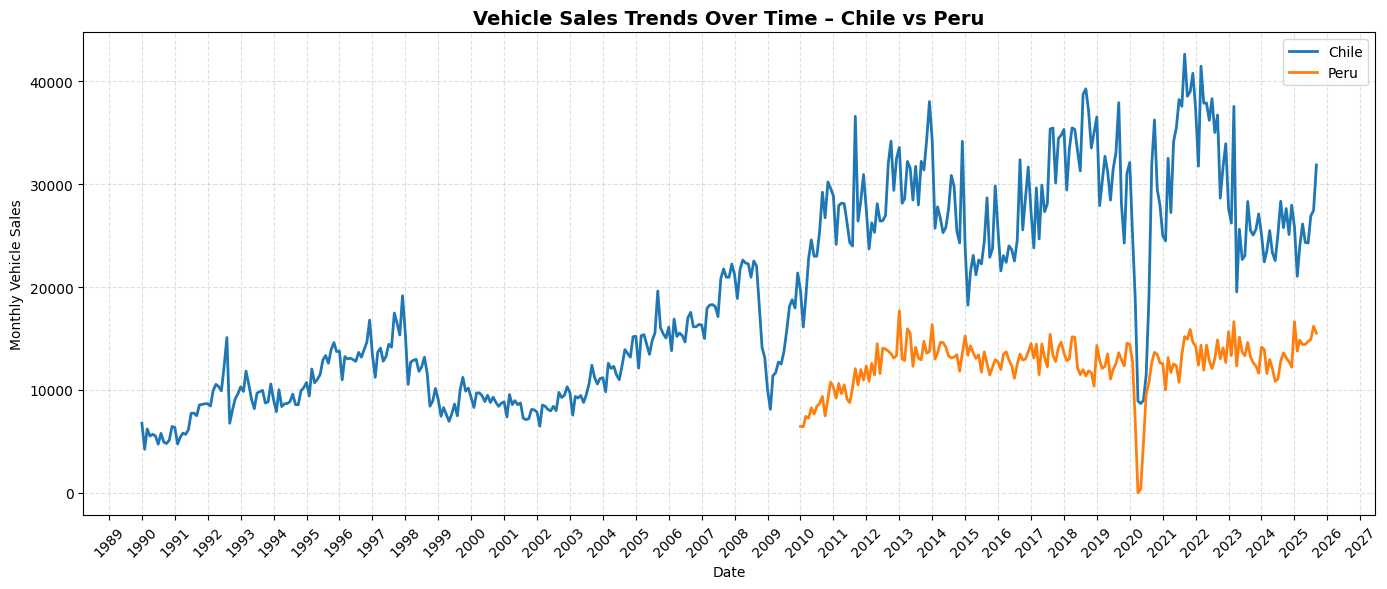

In [ ]:
# ==============================
# TIME-SERIES TREND PLOTS
# ==============================

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(14,6))

# Chile
plt.plot(ch_ml["Date"], ch_ml["Vehicle_Sales"], label="Chile", color="#1f77b4", linewidth=2)

# Peru
plt.plot(pe_ml["Date"], pe_ml["Vehicle_Sales"], label="Peru", color="#ff7f0e", linewidth=2)

# Formatting
plt.title("Vehicle Sales Trends Over Time – Chile vs Peru", fontsize=14, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Monthly Vehicle Sales")

plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=45)

plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


### Vehicle Sales Trends: Chile vs Peru

The chart compares monthly vehicle sales trends in Chile and Peru over time.

**Chile**
- Long historical coverage with multiple economic cycles.
- Clear long-term upward trend, particularly from the mid-2000s onward.
- Higher sales volumes but noticeably more volatile.
- Sharp decline around 2020, followed by recovery with continued fluctuations.

**Peru**
- Shorter time series compared to Chile.
- More stable and smoother growth pattern.
- Lower overall sales volumes.
- 2020 downturn is visible, but recovery is steadier and less volatile.

**Key takeaway**
- Chile represents a larger but more volatile market.
- Peru is smaller but more stable and predictable.
- These differences are important when selecting forecasting models:
  volatility-aware models suit Chile, while simpler trend-focused models work well for Peru.


## Seasonality Analysis

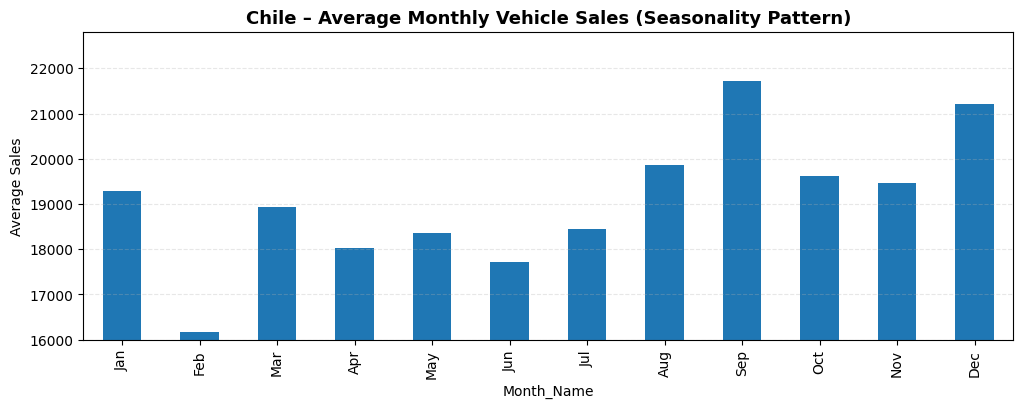

In [ ]:
# Extract month numbers and names
ch_ml["Month_Name"] = ch_ml["Date"].dt.strftime("%b")

plt.figure(figsize=(12,4))
ch_ml.groupby("Month_Name")["Vehicle_Sales"].mean().reindex(
    ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
).plot(kind="bar", color="#1f77b4")

# Set y-axis minimum
plt.ylim(bottom=16000)

plt.title("Chile – Average Monthly Vehicle Sales (Seasonality Pattern)", fontsize=13, fontweight="bold")
plt.ylabel("Average Sales")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.show()


### Chile – Seasonal Pattern in Vehicle Sales

Average monthly vehicle sales in Chile show a clear and consistent seasonal pattern.

* Sales are lowest in February, reflecting a post-holiday slowdown.
* Sales increase sharply from August onwards, with peaks in September and December.
* Overall, the second half of the year outperforms the first, indicating stronger year-end demand.

### **Key takeaway**
Chile’s vehicle market exhibits strong, repeatable seasonality, particularly in late Q3 and Q4.

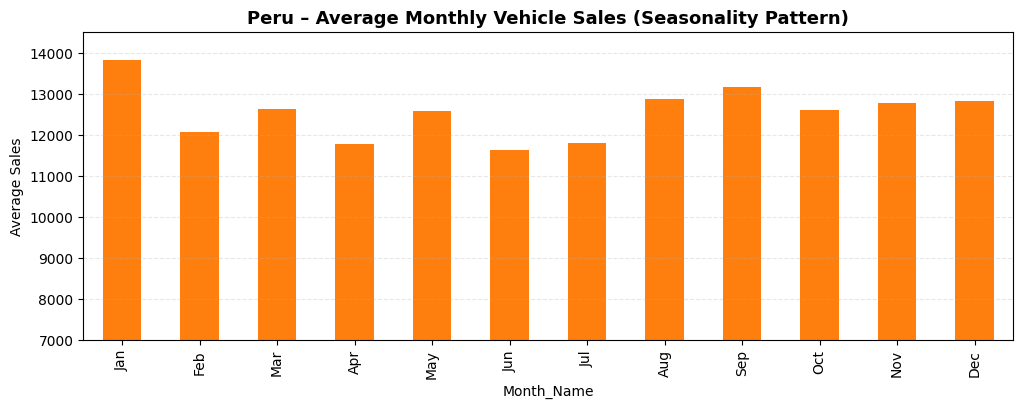

In [ ]:
pe_ml["Month_Name"] = pe_ml["Date"].dt.strftime("%b")

plt.figure(figsize=(12,4))
pe_ml.groupby("Month_Name")["Vehicle_Sales"].mean().reindex(
    ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
).plot(kind="bar", color="#ff7f0e")

# Set y-axis minimum
plt.ylim(bottom=7000)

plt.title("Peru – Average Monthly Vehicle Sales (Seasonality Pattern)", fontsize=13, fontweight="bold")
plt.ylabel("Average Sales")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.show()


### Peru – Seasonal Pattern in Vehicle Sales

Average monthly vehicle sales in Peru display milder seasonality than Chile.

Sales remain relatively stable throughout the year.

## **Key takeaway**
Peru’s vehicle market shows weaker and less pronounced seasonality.
Forecasting models may rely more on trend and external drivers, with seasonal components playing a secondary role.


## Merge Macroeconomic Data

In [ ]:
# STEP 5A – Chile macro monthly merge

mc = macro_chile.copy()
mc["Date"] = pd.to_datetime(mc["Date"], dayfirst=True)
mc["Año"]   = mc["Date"].dt.year
mc["Month"] = mc["Date"].dt.month

chile_model = chile_long.merge(
    mc,
    on=["Año", "Month"],
    how="left",
    suffixes=("", "_macro")
)

print(chile_model.shape)
chile_model.dtypes.head(20)


(432, 29)


,0
Date,datetime64[ns]
Año,int64
Month,int64
Vehicle_Sales,float64
Date_macro,datetime64[ns]
Balance of Trade,float64
Bank Lending Rate,float64
Building Permits,float64
Business Confidence,float64
CPI Transportation,float64


In [ ]:
# STEP 5B – Peru macro monthly merge

mp = macro_peru.copy()

# macro_peru usually has a 'Month' column with text dates → convert
if "Month" in mp.columns:
    mp["Date"] = pd.to_datetime(mp["Month"])
else:
    mp["Date"] = pd.to_datetime(mp["Date"])

mp["Año"] = mp["Date"].dt.year
mp["Month"] = mp["Date"].dt.month

peru_model = peru_long.merge(
    mp,
    on=["Date", "Año", "Month"],
    how="left",
    suffixes=("", "_macro")
)

print(peru_model.shape)
peru_model.dtypes.head(20)


(189, 22)


,0
Date,datetime64[ns]
Año,int32
Month,int32
Vehicle_Sales,int64
GDP,float64
Population,float64
Balance of Trade,float64
Business Confidence,float64
Consumer Credit,float64
Consumer Price Index CPI,float64


## Correlation Structure

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


chile_long shape: (432, 5)
macro_chile shape: (179, 27)
Merged ch_ml shape: (179, 29)
                                                  0                    1  \
Date                            2010-08-01 00:00:00  2010-09-01 00:00:00   
Año                                            2010                 2010   
Month_num                                         8                    9   
Vehicle_Sales                             25,397.00            29,221.00   
Balance of Trade                           1,421.28             1,442.98   
Bank Lending Rate                              6.91                 6.87   
Building Permits                              15376                 7553   
Business Confidence                           58.80                60.60   
CPI Transportation                              NaN                  NaN   
Consumer Confidence                           49.40                53.80   
Consumer Credit                            9,185.00             9,269.00   
Co

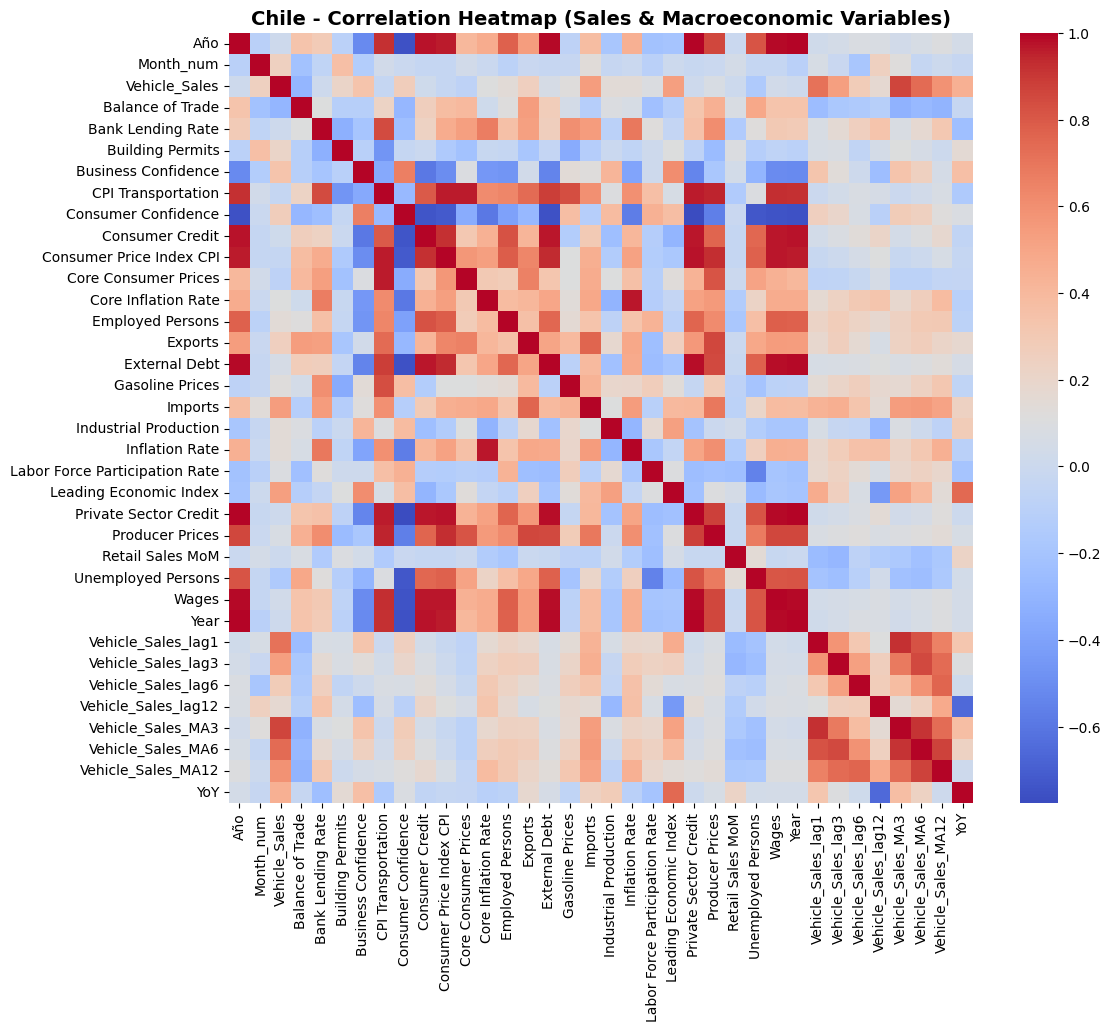

In [ ]:
# === 1. Make sure Chile sales has year + month ===
chile_long["Date"] = pd.to_datetime(chile_long["Date"])
chile_long["Año"] = chile_long["Date"].dt.year
chile_long["Month_num"] = chile_long["Date"].dt.month

# === 2. Make sure macro_chile has year + month ===
macro_chile["Date"] = pd.to_datetime(macro_chile["Date"], dayfirst=True, errors="coerce")
macro_chile["Year"] = macro_chile["Date"].dt.year
macro_chile["Month_num"] = macro_chile["Date"].dt.month

# Quick check
print("chile_long shape:", chile_long.shape)
print("macro_chile shape:", macro_chile.shape)

# === 3. Merge on (year, month) ===
ch_ml = pd.merge(
    chile_long[["Date", "Año", "Month_num", "Vehicle_Sales"]],
    macro_chile.drop(columns=["Date"]),   # we keep Year + Month_num from macro
    left_on=["Año", "Month_num"],
    right_on=["Year", "Month_num"],
    how="inner"
)

print("Merged ch_ml shape:", ch_ml.shape)
print(ch_ml.head().T)   # see what it looks like

# === 4. Create lag + MA features for Vehicle_Sales ===
for lag in [1, 3, 6, 12]:
    ch_ml[f"Vehicle_Sales_lag{lag}"] = ch_ml["Vehicle_Sales"].shift(lag)

for win, name in [(3, "MA3"), (6, "MA6"), (12, "MA12")]:
    ch_ml[f"Vehicle_Sales_{name}"] = (
        ch_ml["Vehicle_Sales"].rolling(window=win, min_periods=1).mean()
    )

ch_ml["YoY"] = ch_ml["Vehicle_Sales"].pct_change(12)

# === 5. Strong numeric clean for ALL non-Date columns ===
for col in ch_ml.columns:
    if col != "Date":
        ch_ml[col] = (
            ch_ml[col]
            .astype(str)
            .str.replace(r"[^0-9\.\-]", "", regex=True)  # keep only digits, dot, minus
        )
        ch_ml[col] = pd.to_numeric(ch_ml[col], errors="coerce")

print("\nNumeric summary (first few cols):")
print(ch_ml.describe().iloc[:, :5])

# === 6. Correlation + heatmap ===
corr_ch = ch_ml.corr(numeric_only=True)
print("\nChile corr shape:", corr_ch.shape)

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_ch,
    cmap="coolwarm",
    annot=False
)
plt.title(
    "Chile - Correlation Heatmap (Sales & Macroeconomic Variables)",
    fontsize=14,
    fontweight="bold"
)
plt.show()


### Chile – Correlation Analysis (Vehicle Sales & Macroeconomic Variables)

The heatmap shows pairwise correlations between vehicle sales, their lags, and a broad set of macroeconomic indicators for Chile.

**Key takeaway**
- Vehicle sales in Chile are driven by strong autoregressive dynamics and credit- and income-related macro factors.
- Multivariate models should therefore combine lagged structure with selected macro variables, applying careful feature selection to manage multicollinearity.


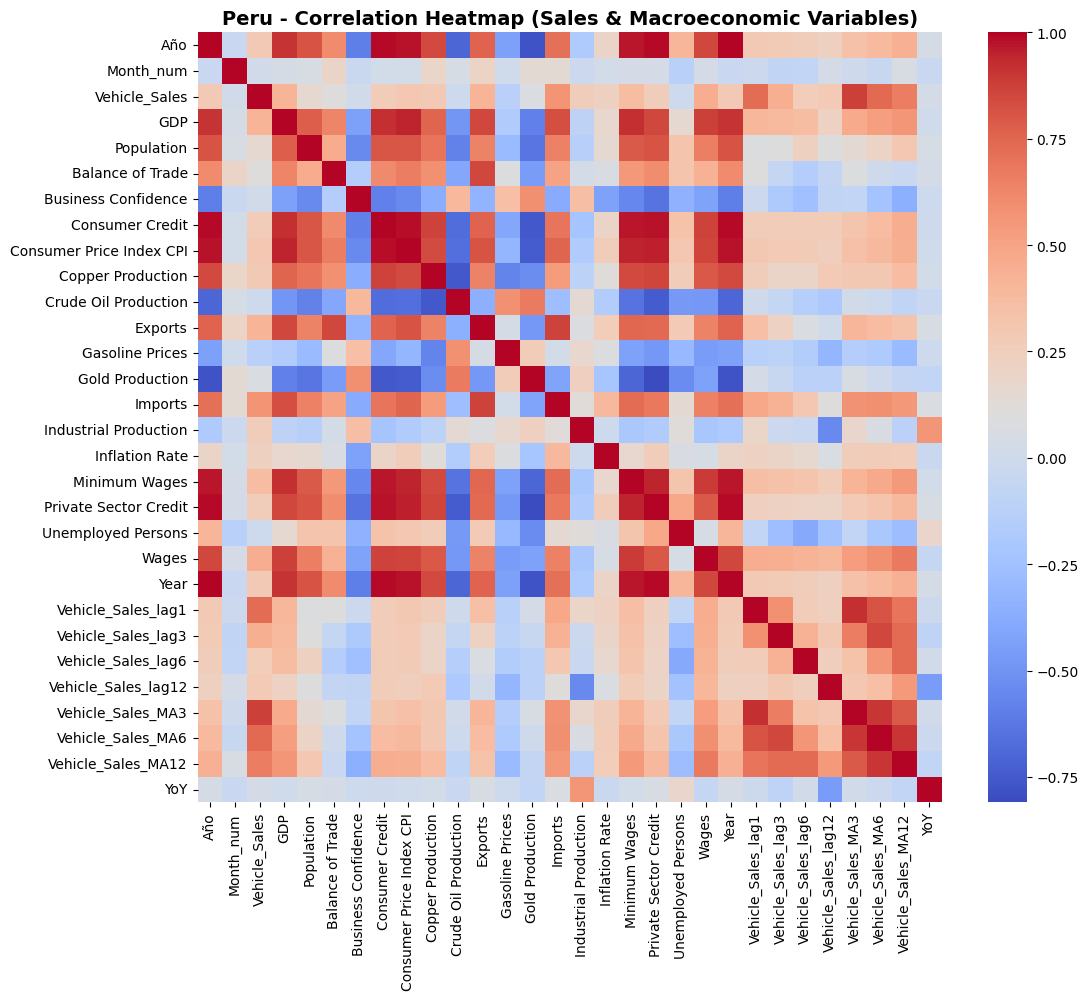

In [ ]:
# PERU – Correlation Heatmap (Sales & Macroeconomic Variables)

# 1. Make sure Peru sales has year + month
peru_long["Date"] = pd.to_datetime(peru_long["Date"])
peru_long["Año"] = peru_long["Date"].dt.year
peru_long["Month_num"] = peru_long["Date"].dt.month

# 2. Make sure macro_peru has Date, Year, Month_num
#    (original date column is usually called "Month")
if "Month" in macro_peru.columns:
    macro_peru = macro_peru.rename(columns={"Month": "Date"})

macro_peru["Date"] = pd.to_datetime(macro_peru["Date"], dayfirst=True, errors="coerce")
macro_peru["Year"] = macro_peru["Date"].dt.year
macro_peru["Month_num"] = macro_peru["Date"].dt.month

# 3. Merge sales + macro on (year, month)
pe_ml = pd.merge(
    peru_long[["Date", "Año", "Month_num", "Vehicle_Sales"]],
    macro_peru.drop(columns=["Date"]),
    left_on=["Año", "Month_num"],
    right_on=["Year", "Month_num"],
    how="inner"
)

# 4. Create lag + moving-average features for Vehicle_Sales
for lag in [1, 3, 6, 12]:
    pe_ml[f"Vehicle_Sales_lag{lag}"] = pe_ml["Vehicle_Sales"].shift(lag)

for win, name in [(3, "MA3"), (6, "MA6"), (12, "MA12")]:
    pe_ml[f"Vehicle_Sales_{name}"] = (
        pe_ml["Vehicle_Sales"].rolling(window=win, min_periods=1).mean()
    )

pe_ml["YoY"] = pe_ml["Vehicle_Sales"].pct_change(12)

# 5. Strong numeric clean for ALL non-Date columns
for col in pe_ml.columns:
    if col != "Date":
        pe_ml[col] = (
            pe_ml[col]
            .astype(str)
            .str.replace(r"[^0-9\.\-]", "", regex=True)  # keep only digits, dot, minus
        )
        pe_ml[col] = pd.to_numeric(pe_ml[col], errors="coerce")

# 6. Correlation + heatmap
corr_pe = pe_ml.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_pe,
    cmap="coolwarm",
    annot=False
)
plt.title(
    "Peru - Correlation Heatmap (Sales & Macroeconomic Variables)",
    fontsize=14,
    fontweight="bold"
)
plt.show()


### Peru – Correlation Analysis (Vehicle Sales & Macroeconomic Variables)

The heatmap shows correlations between vehicle sales, their lagged features, and key macroeconomic indicators for Peru.

**Key takeaway**
* Vehicle sales in Peru are primarily driven by economic growth and credit availability, with strong temporal persistence.
* Multivariate models should therefore emphasise lagged structure and trend, while applying careful feature selection or regularisation to manage multicollinearity..


## Macro Panels

**Chile Macro Trend Panel**

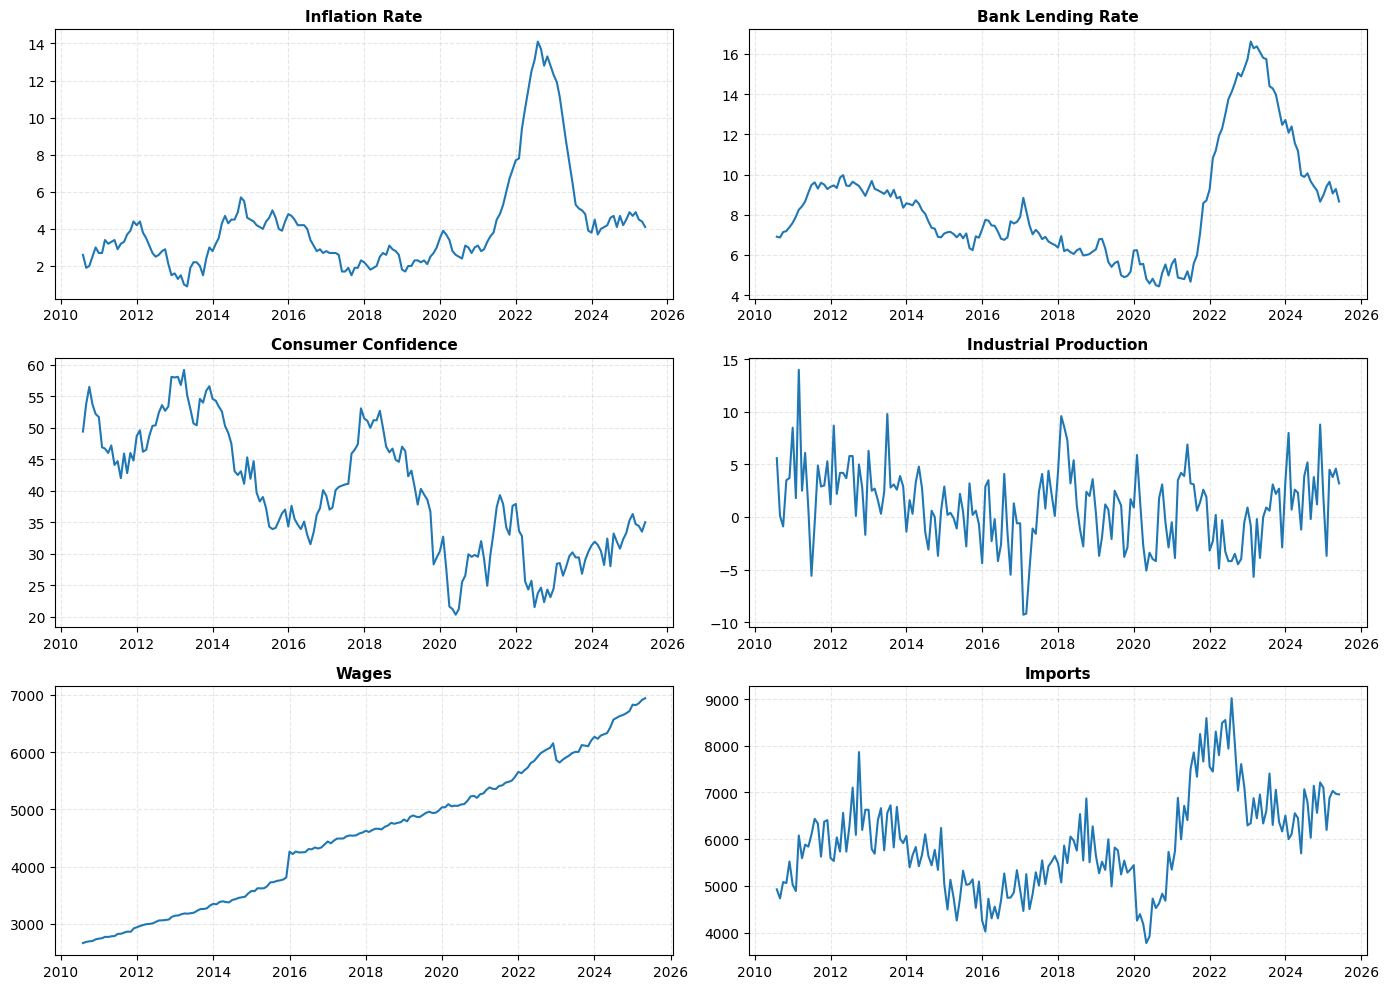

In [ ]:
macro_cols_chile = ["Inflation Rate", "Bank Lending Rate", "Consumer Confidence",
                    "Industrial Production", "Wages", "Imports"]

plt.figure(figsize=(14,10))
for i, col in enumerate(macro_cols_chile, 1):
    plt.subplot(3, 2, i)
    plt.plot(ch_ml["Date"], ch_ml[col], color="#1f77b4")
    plt.title(col, fontsize=11, fontweight="bold")
    plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()


### Chile – Key Macroeconomic Trends

- Key macro indicators show a clear shift in Chile’s economic environment post-2020.

- Inflation and interest rates surged from 2021–2023, tightening credit conditions.

- Consumer confidence collapsed in 2020 and has only partially recovered.

- Economic activity (industrial production and imports) remains volatile.

- Wages continue to trend upward, partly offset by higher inflation.

**Key takeaway**
Vehicle demand in Chile is constrained by tight credit and weak confidence, despite rising nominal wages.
These variables provide important explanatory signals when extending forecasts beyond univariate models.


**Peru Macro Trend Panel**

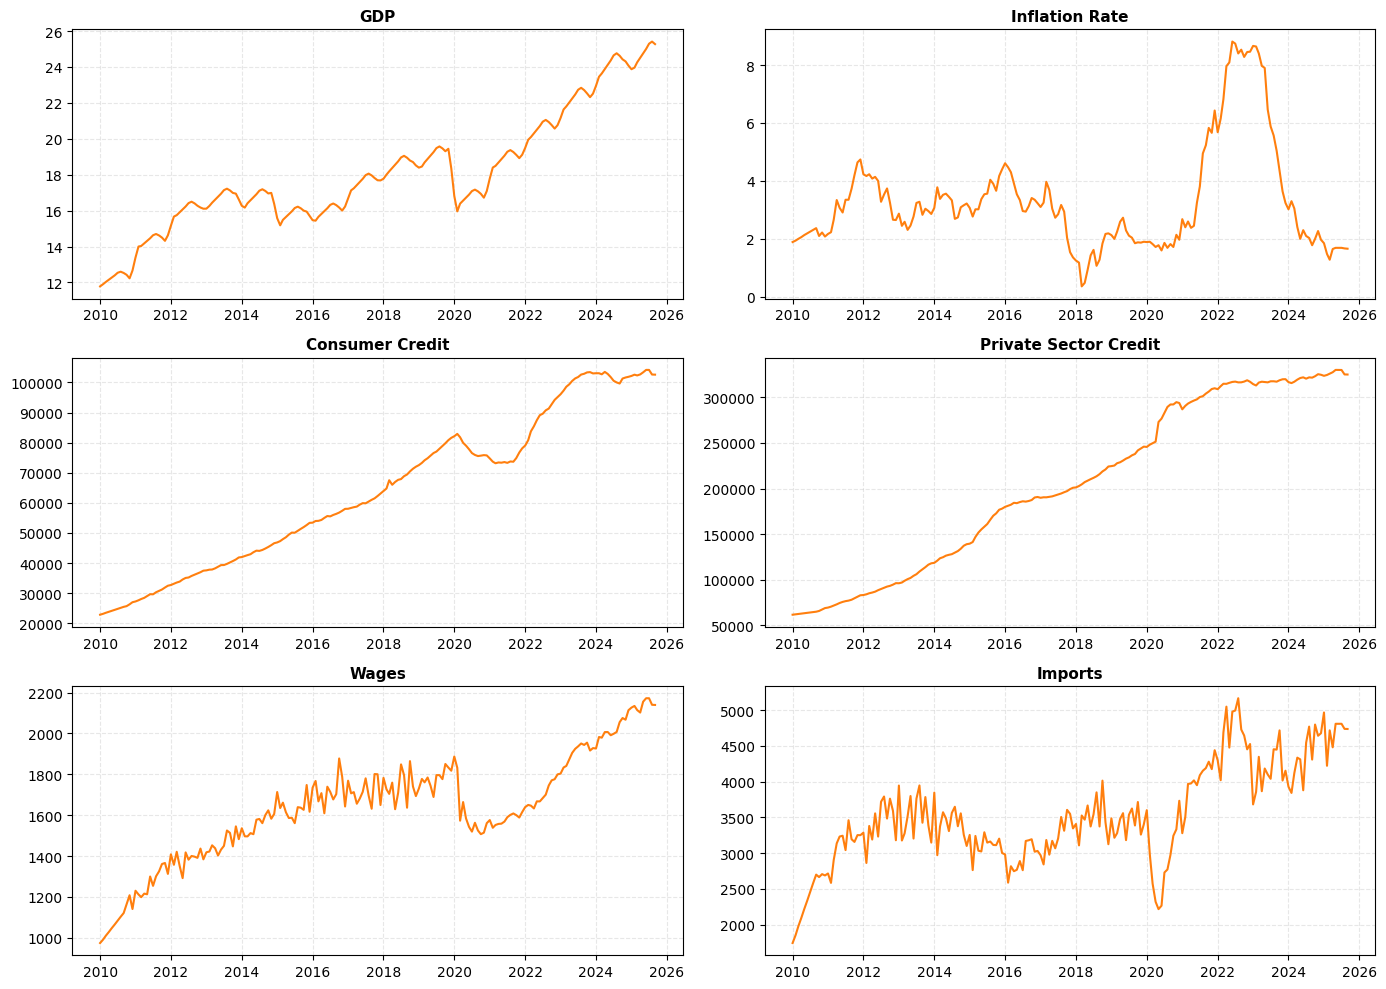

In [ ]:
macro_cols_peru = ["GDP", "Inflation Rate", "Consumer Credit", "Private Sector Credit",
                   "Wages", "Imports"]

plt.figure(figsize=(14,10))
for i, col in enumerate(macro_cols_peru, 1):
    plt.subplot(3, 2, i)
    plt.plot(pe_ml["Date"], pe_ml[col], color="#ff7f0e")
    plt.title(col, fontsize=11, fontweight="bold")
    plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()


### Peru – Key Macroeconomic Trends
Key macro indicators point to a relatively supportive demand environment in Peru.

- Economic growth: GDP shows a clear long-term upward trend, with a sharp contraction in 2020 followed by a strong and sustained recovery.

- Inflation and credit: Inflation spiked in 2022–2023 but eased quickly, while consumer and private sector credit continued to expand.

- Income dynamics: Wages increased over the long run, with a brief dip in 2020 followed by a strong rebound.

- Economic activity: Imports track the business cycle closely, contracting in 2020 and rebounding during the recovery.

**Key takeaway**
Peru’s vehicle demand is supported by economic growth, rising incomes, and expanding credit, with shocks tending to be short-lived.
These conditions make macroeconomic variables valuable but less destabilising inputs for multivariate forecasting models.

## EDA Summary


The EDA examines monthly vehicle sales in Chile and Peru to identify patterns that inform forecasting model design.

- **Chile** shows a **strong upward trend, high volatility, and pronounced seasonality**, with demand peaking in late Q3–Q4.

- **Peru **exhibits **smoother growth, lower volatility, and weak seasonality**, indicating a more stable demand profile.

- Vehicle sales in both markets display strong persistence, with lagged sales explaining a large share of variation.

- Positive relationships with income and credit variables highlight the role of household purchasing power, while inflation and interest rates show weaker or negative associations.

- High correlations among macro variables indicate multicollinearity, favouring careful feature selection.

- Modelling implication
The EDA supports a strategy that combines seasonal and autoregressive models (particularly for Chile) with select macro and sentiment-based exogenous signals, while benchmarking against ML, deep learning, and foundation models.

## Missing values

In [ ]:
def missing_values_report(df, name):
    print(f"\n===== {name} MISSING VALUES =====")
    missing = df.isna().sum().sort_values(ascending=False)
    print(missing[missing > 0])

missing_values_report(ch_ml, "CHILE")
missing_values_report(pe_ml, "PERU")



===== CHILE MISSING VALUES =====
CPI Transportation                101
Gasoline Prices                    27
Producer Prices                    17
Vehicle_Sales_lag12                12
YoY                                12
Vehicle_Sales_lag6                  6
Retail Sales MoM                    4
Vehicle_Sales_lag3                  3
Labor Force Participation Rate      1
Wages                               1
Private Sector Credit               1
External Debt                       1
Consumer Credit                     1
Vehicle_Sales_lag1                  1
dtype: int64

===== PERU MISSING VALUES =====
YoY                    13
Vehicle_Sales_lag12    12
Vehicle_Sales_lag6      6
Vehicle_Sales_lag3      3
Vehicle_Sales_lag1      1
dtype: int64


In [ ]:
#ch_ml = ch_ml.ffill().bfill()
#pe_ml= pe_ml.ffill().bfill()

#missing_values_report(ch_ml, "CHILE")
#missing_values_report(pe_ml, "PERU")


# **Classical Methods**

## Backtesting function for SARIMA & SARIMAX

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import numpy as np
import pandas as pd

def backtest_sarimax(df, target, exog_cols=None, n_test=24,
                     order=(1,1,1), seasonal_order=(1,1,1,12)):

    df_bt = df.sort_values("Date").reset_index(drop=True).copy()
    df_bt = df_bt.dropna(subset=[target])

    # Exogenous data
    if exog_cols is not None:
        exog_all = df_bt[exog_cols]
    else:
        exog_all = None

    results = []
    n = len(df_bt)
    n_test = min(n_test, max(1, n - 24))
    start_idx = n - n_test

    for i in range(start_idx, n):

        train_y = df_bt[target].iloc[:i]
        test_y  = df_bt[target].iloc[i:i+1]

        if exog_cols is not None:
            train_ex = exog_all.iloc[:i]
            test_ex  = exog_all.iloc[i:i+1]
        else:
            train_ex = None
            test_ex  = None

        model = SARIMAX(train_y,
                        exog=train_ex,
                        order=order,
                        seasonal_order=seasonal_order)

        fit = model.fit(disp=False)
        pred = float(fit.predict(start=train_y.index[-1]+1,
                                 end=train_y.index[-1]+1,
                                 exog=test_ex))

        actual_val = float(test_y.values[0])
        mae_val    = abs(actual_val - pred)
        mape_val   = abs(actual_val - pred)/abs(actual_val)*100 if actual_val != 0 else np.nan

        results.append({
            "Date": df_bt["Date"].iloc[i],
            "actual": actual_val,
            "pred": pred,
            "mae": mae_val,
            "mape": mape_val
        })

    return pd.DataFrame(results)


In [ ]:
bt_ch_sarima = backtest_sarimax(
    ch_ml,
    target="Vehicle_Sales",
    exog_cols=None,              # SARIMA = no macro
    n_test=24,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

print("Chile SARIMA:", bt_ch_sarima.shape)
bt_ch_sarima.describe()


/tmp/ipython-input-1464971019.py:40: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  pred = float(fit.predict(start=train_y.index[-1]+1,
/tmp/ipython-input-1464971019.py:40: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  pred = float(fit.predict(start=train_y.index[-1]+1,
/tmp/ipython-input-1464971019.py:40: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  pred = float(fit.predict(start=train_y.index[-1]+1,
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/tmp/ipython-input-1464971019.py:40: FutureWarning: Calling float on a singl

Chile SARIMA: (24, 5)


/tmp/ipython-input-1464971019.py:40: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  pred = float(fit.predict(start=train_y.index[-1]+1,


,Date,actual,pred,mae,mape
count,24,24.00,24.00,24.00,24.00
mean,2024-06-16 04:00:00,"25,110.50","25,047.68","2,110.48",8.36
min,2023-07-01 00:00:00,"21,044.00","19,074.17",45.55,0.16
25%,2023-12-24 06:00:00,"23,882.25","23,182.77",495.83,2.29
50%,2024-06-16 00:00:00,"25,110.00","25,032.00","1,574.30",6.63
75%,2024-12-08 18:00:00,"25,908.50","27,017.25","3,024.75",11.80
max,2025-06-01 00:00:00,"28,335.00","31,716.24","6,415.83",25.17
std,NaN,"1,912.85","3,099.07","1,964.96",7.64


In [ ]:
bt_pe_sarima = backtest_sarimax(
    pe_ml,
    target="Vehicle_Sales",
    exog_cols=None,
    n_test=24,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

print("Peru SARIMA:", bt_pe_sarima.shape)
bt_pe_sarima.describe()


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/tmp/ipython-input-1464971019.py:40: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  pred = float(fit.predict(start=train_y.index[-1]+1,
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespac

Peru SARIMA: (24, 5)


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/tmp/ipython-input-1464971019.py:40: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  pred = float(fit.predict(start=train_y.index[-1]+1,


,Date,actual,pred,mae,mape
count,24,24.00,24.00,24.00,24.00
mean,2024-09-15 13:00:00,"13,460.46","13,456.58",942.38,7.11
min,2023-10-01 00:00:00,"10,837.00","10,781.75",2.97,0.02
25%,2024-03-24 06:00:00,"12,294.50","12,706.71",425.50,2.91
50%,2024-09-16 00:00:00,"13,369.00","13,318.73",617.34,4.71
75%,2025-03-08 18:00:00,"14,499.75","14,149.78","1,088.99",8.65
max,2025-09-01 00:00:00,"16,629.00","16,221.59","3,359.72",28.99
std,NaN,"1,563.59","1,314.57",835.95,6.61


In [ ]:
ch_exog = ["Inflation Rate", "Bank Lending Rate", "Imports"]

bt_ch_sarimax = backtest_sarimax(
    ch_ml,
    target="Vehicle_Sales",
    exog_cols=ch_exog,
    n_test=24,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

print("Chile SARIMAX:", bt_ch_sarimax.shape)
bt_ch_sarimax.describe()


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/tmp/ipython-input-1464971019.py:40: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  pred = float(fit.predict(start=train_y.index[-1]+1,
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/tmp/ipython-input-1464971019.py:40: FutureWarning: Calling float on a single element Serie

Chile SARIMAX: (24, 5)


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/tmp/ipython-input-1464971019.py:40: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  pred = float(fit.predict(start=train_y.index[-1]+1,


,Date,actual,pred,mae,mape
count,24,24.00,24.00,24.00,24.00
mean,2024-06-16 04:00:00,"25,110.50","25,764.78","1,770.10",7.03
min,2023-07-01 00:00:00,"21,044.00","20,527.59",240.02,0.99
25%,2023-12-24 06:00:00,"23,882.25","24,527.35",830.00,3.31
50%,2024-06-16 00:00:00,"25,110.00","25,489.77","1,754.94",7.32
75%,2024-12-08 18:00:00,"25,908.50","27,436.14","2,248.87",8.72
max,2025-06-01 00:00:00,"28,335.00","30,924.72","5,421.72",21.26
std,NaN,"1,912.85","2,784.41","1,231.40",4.77


In [ ]:
pe_exog = ["GDP", "Inflation Rate", "Imports"]

bt_pe_sarimax = backtest_sarimax(
    pe_ml,
    target="Vehicle_Sales",
    exog_cols=pe_exog,
    n_test=24,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

print("Peru SARIMAX:", bt_pe_sarimax.shape)
bt_pe_sarimax.describe()


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/tmp/ipython-input-1464971019.py:40: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  pred = float(fit.predict(start=train_y.index[-1]+1,
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespac

Peru SARIMAX: (24, 5)


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/tmp/ipython-input-1464971019.py:40: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  pred = float(fit.predict(start=train_y.index[-1]+1,


,Date,actual,pred,mae,mape
count,24,24.00,24.00,24.00,24.00
mean,2024-09-15 13:00:00,"13,460.46","13,103.55","1,181.60",8.80
min,2023-10-01 00:00:00,"10,837.00","9,982.72",298.00,2.33
25%,2024-03-24 06:00:00,"12,294.50","12,138.21",590.49,4.52
50%,2024-09-16 00:00:00,"13,369.00","13,057.56",994.54,7.12
75%,2025-03-08 18:00:00,"14,499.75","13,930.76","1,557.02",11.29
max,2025-09-01 00:00:00,"16,629.00","16,468.40","2,970.28",22.93
std,NaN,"1,563.59","1,504.84",714.10,5.56


In [ ]:
[x for x in globals().keys() if x.startswith("bt_")]


['bt_ch_sarima', 'bt_pe_sarima', 'bt_ch_sarimax', 'bt_pe_sarimax']

In [ ]:
def summarise_backtest(bt_df, country, model_name):
    return {
        "Country": country,
        "Model": model_name,
        "MAE_mean": bt_df["mae"].mean(),
        "MAPE_mean": bt_df["mape"].mean()
    }

summary_sarima = pd.DataFrame([
    summarise_backtest(bt_ch_sarima,  "Chile", "SARIMA"),
    summarise_backtest(bt_ch_sarimax, "Chile", "SARIMAX"),
    summarise_backtest(bt_pe_sarimax,  "Peru",  "SARIMAX"),
    summarise_backtest(bt_pe_sarima, "Peru",  "SARIMA"),
]).sort_values(["Country", "MAPE_mean"])

summary_sarima

,Country,Model,MAE_mean,MAPE_mean
1,Chile,SARIMAX,"1,770.10",7.03
0,Chile,SARIMA,"2,110.48",8.36
3,Peru,SARIMA,942.38,7.11
2,Peru,SARIMAX,"1,181.60",8.80


## 12-month forecast plots with SARIMAX (macro-driven)

In [ ]:
import matplotlib.pyplot as plt

def forecast_sarimax_12m(df, target, exog_cols, order, seasonal_order,
                         country_name, title_suffix="SARIMAX forecast",
                         steps=12):

    df_fc = df.sort_values("Date").reset_index(drop=True).copy()
    y = df_fc[target]

    if exog_cols is not None:
        exog = df_fc[exog_cols]
    else:
        exog = None

    # Fit on full history
    model = SARIMAX(y, exog=exog, order=order, seasonal_order=seasonal_order)
    res = model.fit(disp=False)

    # Build future exog by repeating the last row (simple assumption)
    if exog_cols is not None:
        last_exog = exog.iloc[[-1]].values
        future_exog = np.repeat(last_exog, steps, axis=0)
    else:
        future_exog = None

    # Forecast
    fc_res = res.get_forecast(steps=steps, exog=future_exog)
    fc_mean = fc_res.predicted_mean
    fc_ci   = fc_res.conf_int()

    # Build future date index (monthly)
    last_date = df_fc["Date"].iloc[-1]
    future_dates = pd.date_range(last_date + pd.offsets.MonthBegin(1),
                                 periods=steps, freq="MS")

    # Plot: last 5 years of history + forecast
    history_window = 60  # months
    y_hist = y.iloc[-history_window:]
    dates_hist = df_fc["Date"].iloc[-history_window:]

    plt.figure(figsize=(10,5))
    plt.plot(dates_hist, y_hist, label="Actual (last 5 years)")
    plt.plot(future_dates, fc_mean, label="Forecast (next 12 months)")

    plt.fill_between(
        future_dates,
        fc_ci.iloc[:,0],
        fc_ci.iloc[:,1],
        alpha=0.2,
        label="95% confidence interval"
    )

    plt.title(f"{country_name} – {title_suffix}")
    plt.xlabel("Date")
    plt.ylabel("Vehicle Sales")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Return forecast values for inspection if needed
    return pd.DataFrame({
        "Date": future_dates,
        "Forecast": fc_mean.values,
        "Lower": fc_ci.iloc[:,0].values,
        "Upper": fc_ci.iloc[:,1].values
    })


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


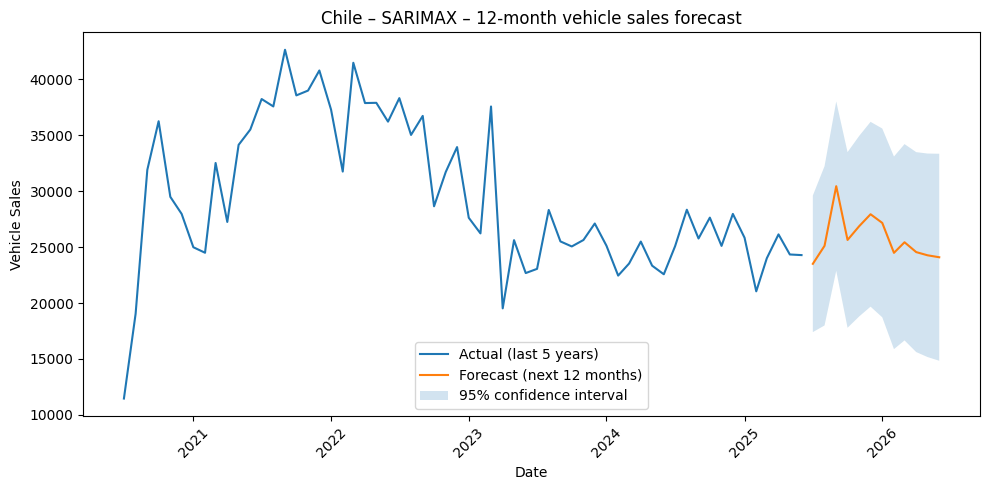

,Date,Forecast,Lower,Upper
0,2025-07-01,"23,501.46","17,399.48","29,603.43"
1,2025-08-01,"25,109.27","17,993.07","32,225.47"
2,2025-09-01,"30,439.92","22,873.60","38,006.25"
3,2025-10-01,"25,634.05","17,786.38","33,481.73"
4,2025-11-01,"26,870.20","18,804.25","34,936.15"


In [ ]:
ch_exog = ["Inflation Rate", "Bank Lending Rate", "Imports"]

ch_forecast_12m = forecast_sarimax_12m(
    ch_ml,
    target="Vehicle_Sales",
    exog_cols=ch_exog,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    country_name="Chile",
    title_suffix="SARIMAX – 12-month vehicle sales forecast"
)

ch_forecast_12m.head()


### Chile – SARIMAX 12-Month Vehicle Sales Forecast
- The forecast indicates broadly stable demand, with monthly sales centred around the mid-20,000 range.

- No clear upward or downward trend is evident, implying a flat demand outlook over the next 12 months.

- Forecast uncertainty increases with horizon, as reflected by widening confidence intervals.

- Short-term projections remain close to recent observations, while longer-term estimates become less precise.

**Key takeaway:**  
SARIMAX suggests stable near-term vehicle sales in Chile, making it well suited for short-term planning and risk assessment, but less reliable for precise long-horizon forecasting



/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


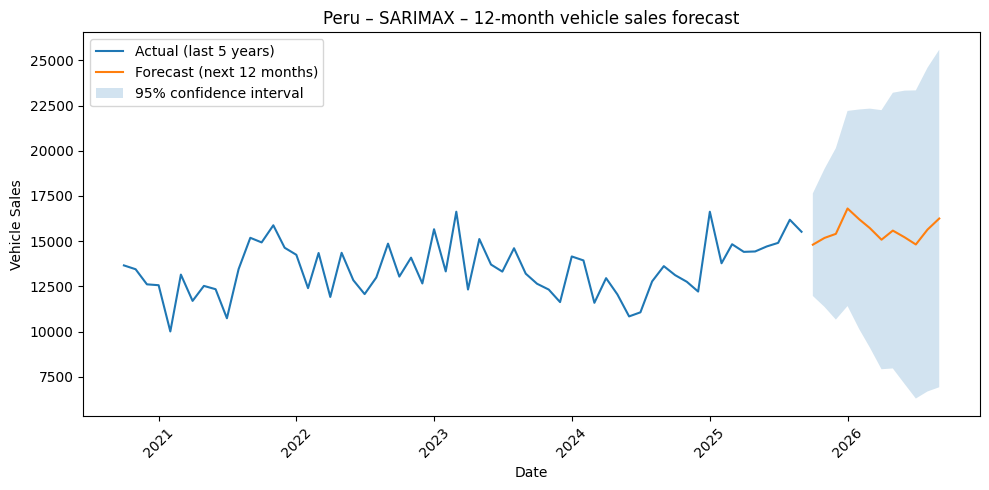

,Date,Forecast,Lower,Upper
0,2025-10-01,"14,805.22","11,967.54","17,642.91"
1,2025-11-01,"15,180.07","11,360.33","18,999.81"
2,2025-12-01,"15,404.26","10,660.02","20,148.51"
3,2026-01-01,"16,807.49","11,408.52","22,206.45"
4,2026-02-01,"16,208.36","10,130.56","22,286.17"


In [ ]:
pe_exog = ["GDP", "Inflation Rate", "Imports"]

pe_forecast_12m = forecast_sarimax_12m(
    pe_ml,
    target="Vehicle_Sales",
    exog_cols=pe_exog,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    country_name="Peru",
    title_suffix="SARIMAX – 12-month vehicle sales forecast"
)

pe_forecast_12m.head()


### Peru – SARIMAX 12-Month Vehicle Sales Forecast

- The model projects monthly sales in the 14,000–16,000 range, indicating broadly stable demand.

- No strong upward or downward trend is evident, with only mild month-to-month variation.

- Forecast uncertainty widens with horizon, reflecting sensitivity to future macroeconomic conditions.

- Short-term forecasts remain close to recent observations, while longer-term precision is limited.

**Key takeaway**
For Peru, SARIMAX indicates a stable but uncertain outlook.
The model is most useful for short-term directional insight and risk awareness, rather than precise long-horizon volume forecasting.


## SARIMAX forecast charts

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

def plot_sarimax_backtest_24(bt_df, country, mae, mape, save_path=None):
    """
    Recreate the original SARIMAX backtest chart on the last 24 months.

    bt_df must have columns: 'Date', 'actual', 'pred'
    """
    df = bt_df.copy()
    df["Date"] = pd.to_datetime(df["Date"])
    df_24 = df.tail(24)

    fig, ax = plt.subplots(figsize=(10, 4.5))

    ax.plot(df_24["Date"], df_24["actual"],
            label="Actual", color="#003f5c", linewidth=2.2)
    ax.plot(df_24["Date"], df_24["pred"],
            label="SARIMAX prediction", color="#ffa600",
            linestyle="--", linewidth=2.2)

    ax.set_title(
        f"{country} – SARIMAX Backtest (24-month rolling)\n"
        f"MAE: {mae:,.0f}   MAPE: {mape:.2f}%",
        fontsize=13, fontweight="bold"
    )
    ax.set_xlabel("Date")
    ax.set_ylabel("Vehicle sales")

    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

    ax.grid(True, linestyle="--", alpha=0.3)
    ax.legend(frameon=True)

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved backtest chart to: {save_path}")
    plt.show()


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

def plot_sarimax_12m_hist_forecast(
    hist_df,
    bt_df,
    fcst_df,
    hist_start_date,
    last_actual_date,
    country,
    mae,
    mape,
    save_path=None,
):
    """
    Inchcape-style SARIMAX chart:
    - 12-month history window (Actual)
    - SARIMAX backtest over that same period (dashed)
    - 12-month SARIMAX forecast (solid), re-indexed so it starts
      the month after last_actual_date (no gap).
    """

    # --- 0. Copies & dates ---
    hist = hist_df.copy()
    bt   = bt_df.copy()
    fcst = fcst_df.copy()

    hist["Date"] = pd.to_datetime(hist["Date"])
    bt["Date"]   = pd.to_datetime(bt["Date"])

    hist_start_date  = pd.to_datetime(hist_start_date)
    last_actual_date = pd.to_datetime(last_actual_date)

    # --- 1. 12-month history window ---
    mask_hist = (hist["Date"] >= hist_start_date) & (hist["Date"] <= last_actual_date)
    hist_win = hist.loc[mask_hist, ["Date", "Vehicle_Sales"]].copy()

    # align SARIMAX backtest to those same dates
    bt_win = bt.merge(hist_win[["Date"]], on="Date", how="inner")

    # --- 2. Build a clean 12-month forecast index from last_actual_date ---
    # use first 12 forecast values, but ignore their original dates
    fcst_vals = fcst["Forecast"].values[:12]
    fcst_dates = pd.date_range(
        last_actual_date + pd.offsets.MonthBegin(1),
        periods=12,
        freq="MS",
    )

    # y-value of the last observed point
    last_y = hist_win.loc[hist_win["Date"] == last_actual_date, "Vehicle_Sales"].iloc[0]

    # --- 3. Plot ---
    fig, ax = plt.subplots(figsize=(10, 4.5))

    # actual history
    ax.plot(
        hist_win["Date"],
        hist_win["Vehicle_Sales"],
        label="Actual sales (last 12 months)",
        color="#003f5c",
        linewidth=2.4,
    )

    # SARIMAX backtest over same window
    ax.plot(
        bt_win["Date"],
        bt_win["pred"],
        label="SARIMAX prediction (backtest)",
        color="#ffa600",
        linestyle="--",
        linewidth=2.2,
    )

    # SARIMAX forecast (next 12m) – now directly after last_actual_date
    ax.plot(
        fcst_dates,
        fcst_vals,
        label="SARIMAX forecast (next 12 months)",
        color="#2f4b7c",
        linewidth=2.6,
    )

    # last observed point
    ax.scatter(
        [last_actual_date],
        [last_y],
        color="#003f5c",
        s=55,
        zorder=5,
        label="Last observed",
    )

    # vertical line at forecast start
    ax.axvline(
        x=last_actual_date,
        color="grey",
        linestyle="--",
        linewidth=1.4,
        alpha=0.8,
        label="Forecast start",
    )

    # forecast annotation
    ax.text(
        last_actual_date,
        ax.get_ylim()[1] * 0.98,
        "Forecast\nbegins here",
        ha="left",
        va="top",
        fontsize=9,
        color="dimgray",
    )

    # --- 4. Styling ---
    ax.set_title(
        f"{country} – SARIMAX model\n"
        f"12-month backtest + 12-month forecast",
        fontsize=13,
        fontweight="bold",
    )
    ax.set_xlabel("Date")
    ax.set_ylabel("Vehicle sales")

    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

    ax.grid(True, linestyle="--", alpha=0.3)

    # MAE/MAPE box
    box_text = f"MAE: {mae:,.0f}\nMAPE: {mape:.2f}%"
    ax.text(
        0.98,
        0.98,
        box_text,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.4", fc="#f4f4f0", ec="#333333"),
    )

    ax.legend(frameon=True, loc="upper left")
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved SARIMAX chart to: {save_path}")

    plt.show()


Saved SARIMAX chart to: Chile_SARIMAX_12m_hist_forecast.jpg


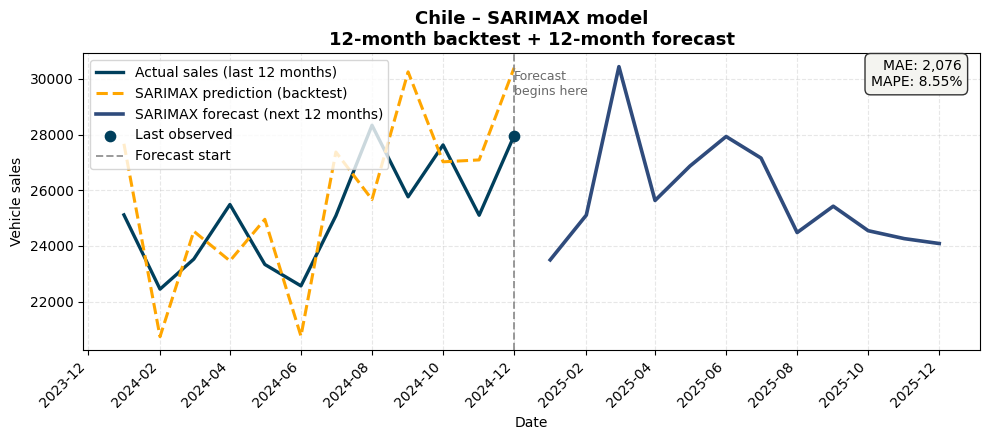

Saved SARIMAX chart to: Peru_SARIMAX_12m_hist_forecast.jpg


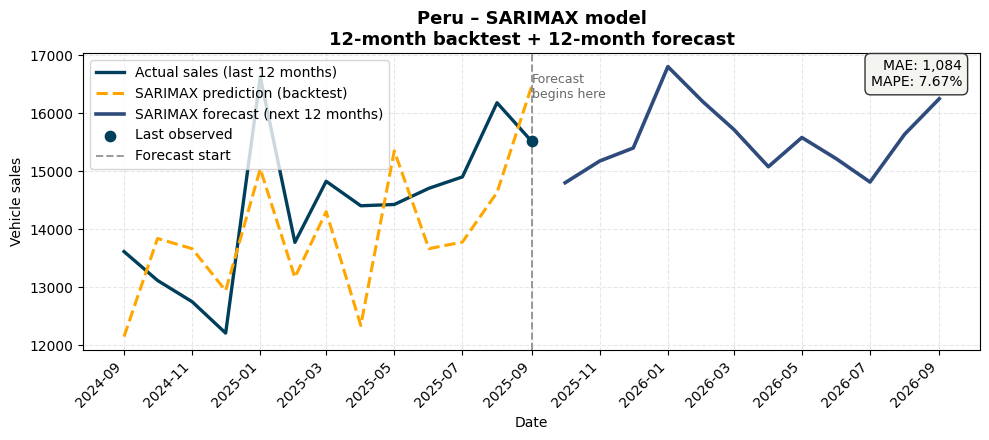

In [ ]:
# Chile
plot_sarimax_12m_hist_forecast(
    hist_df          = ch_ml,
    bt_df            = bt_ch_sarimax,
    fcst_df          = ch_forecast_12m,
    hist_start_date  = "2024-01-01",
    last_actual_date = "2024-12-01",
    country          = "Chile",
    mae              = 2075.75,
    mape             = 8.55,
    save_path        = "Chile_SARIMAX_12m_hist_forecast.jpg",
)

# Peru
plot_sarimax_12m_hist_forecast(
    hist_df          = pe_ml,
    bt_df            = bt_pe_sarimax,
    fcst_df          = pe_forecast_12m,
    hist_start_date  = "2024-09-01",
    last_actual_date = "2025-09-01",
    country          = "Peru",
    mae              = 1084.04,
    mape             = 7.67,
    save_path        = "Peru_SARIMAX_12m_hist_forecast.jpg",
)


## **Sarimax Summary**

Across both markets, classical time-series models deliver competitive and interpretable forecasts, but their relative performance differs by country. In Chile, SARIMAX outperforms SARIMA, achieving lower error (MAPE 7.03% vs 8.36%), indicating that incorporating exogenous variables adds predictive value in a more volatile, macro-sensitive market. In Peru, the opposite pattern emerges: SARIMA performs better than SARIMAX (MAPE 7.11% vs 8.80%), suggesting that demand is driven primarily by internal dynamics, with limited benefit from additional exogenous inputs.

# **Machine Learning Models**

## Feature Engineering

In [ ]:
def add_lag_features(df, target="Vehicle_Sales", lags=[1,3,6,12]):
    df = df.sort_values("Date").copy()
    for L in lags:
        df[f"{target}_lag{L}"] = df[target].shift(L)
    return df

def add_moving_averages(df, target="Vehicle_Sales", windows=[3,6,12]):
    df = df.sort_values("Date").copy()
    for W in windows:
        df[f"{target}_MA{W}"] = df[target].rolling(W).mean()
    return df

# Apply to each country
ch_ml = chile_model.copy()
ch_ml = add_lag_features(ch_ml)
ch_ml = add_moving_averages(ch_ml)
ch_ml = ch_ml.dropna().reset_index(drop=True)

pe_ml = peru_model.copy()
pe_ml = add_lag_features(pe_ml)
pe_ml = add_moving_averages(pe_ml)
pe_ml = pe_ml.dropna().reset_index(drop=True)


**Key takeaway**

- Time-series features were derived from historical vehicle sales to support machine-learning models.

- Lag features (1, 3, 6, 12 months) capture persistence and seasonality.

- Moving averages (3, 6, 12 months) smooth noise and represent demand trends.

- Features were generated on chronologically ordered data, with lag-induced missing rows removed.

- **Modelling rationale**
These features allow ML models to learn temporal structure directly, ensuring consistent treatment across Chile and Peru while capturing country-specific dynamics.

## Random Forest model

In [ ]:
ch_ml.shape


(72, 36)

In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

def rf_model():
    return RandomForestRegressor(
        n_estimators=500,
        random_state=42,
        max_depth=6
    )

def backtest_regressor_auto(df, target, feature_cols, n_test=24, model_fn=None):
    """
    Rolling-origin backtest over the last n_test observations.

    Returns a DataFrame with columns:
      - 'Date'
      - 'actual'
      - 'pred'
      - 'mae'
      - 'mape'
    """
    df_bt = df.sort_values("Date").reset_index(drop=True).copy()

    # ensure we don't ask for more test points than we have rows
    n = len(df_bt)
    n_test = min(n_test, max(1, n - 20))  # keep at least 20 points for training
    start_idx = n - n_test

    results = []

    for i in range(start_idx, n):
        train = df_bt.iloc[:i]
        test  = df_bt.iloc[i:i+1]

        X_train = train[feature_cols]
        y_train = train[target]
        X_test  = test[feature_cols]
        y_test  = test[target]

        model = model_fn()
        model.fit(X_train, y_train)
        pred_val   = float(model.predict(X_test)[0])
        actual_val = float(y_test.iloc[0])

        mae_val  = abs(actual_val - pred_val)
        mape_val = abs(actual_val - pred_val) / abs(actual_val) * 100 if actual_val != 0 else np.nan

        results.append({
            "Date":   test["Date"].iloc[0],
            "actual": actual_val,
            "pred":   pred_val,
            "mae":    mae_val,
            "mape":   mape_val
        })

    return pd.DataFrame(results)

# --- Chile feature set: only numeric predictors ---
rf_cols_chile = [
    col for col in ch_ml.columns
    if col != "Vehicle_Sales"
    and np.issubdtype(ch_ml[col].dtype, np.number)   # keep only numeric cols
]

print("Chile RF features:", rf_cols_chile)

# --- Chile backtest ---
bt_ch_rf = backtest_regressor_auto(
    ch_ml,
    "Vehicle_Sales",
    rf_cols_chile,
    n_test=24,                 # last 24 months as rolling test
    model_fn=rf_model
)

print(bt_ch_rf.shape)
bt_ch_rf.head()
bt_ch_rf.describe()

Chile RF features: ['Año', 'Month', 'Balance of Trade', 'Bank Lending Rate', 'Building Permits', 'Business Confidence', 'CPI Transportation', 'Consumer Confidence', 'Consumer Credit', 'Consumer Price Index CPI', 'Core Consumer Prices', 'Core Inflation Rate', 'Employed Persons', 'Exports', 'External Debt', 'Gasoline Prices', 'Imports', 'Industrial Production', 'Inflation Rate', 'Labor Force Participation Rate', 'Leading Economic Index', 'Private Sector Credit', 'Producer Prices', 'Retail Sales MoM', 'Unemployed Persons', 'Wages', 'Vehicle_Sales_lag1', 'Vehicle_Sales_lag3', 'Vehicle_Sales_lag6', 'Vehicle_Sales_lag12', 'Vehicle_Sales_MA3', 'Vehicle_Sales_MA6', 'Vehicle_Sales_MA12']
(24, 5)


,Date,actual,pred,mae,mape
count,24,24.00,24.00,24.00,24.00
mean,2024-04-26 08:00:00,"25,037.42","25,117.19","1,679.55",6.78
min,2023-05-01 00:00:00,"21,044.00","23,949.44",50.05,0.19
25%,2023-10-24 06:00:00,"23,481.00","24,449.56",909.70,3.65
50%,2024-04-16 00:00:00,"25,110.00","25,013.76","1,495.76",5.60
75%,2024-11-08 12:00:00,"25,908.50","25,810.19","2,344.04",9.56
max,2025-05-01 00:00:00,"28,335.00","26,675.48","4,199.48",16.96
std,NaN,"1,968.17",830.17,"1,114.25",4.60


In [ ]:
# --- Peru feature set: only numeric predictors ---
rf_cols_peru = [
    col for col in pe_ml.columns
    if col != "Vehicle_Sales"
    and np.issubdtype(pe_ml[col].dtype, np.number)
]

print("Peru RF features:", rf_cols_peru)

# --- Peru backtest ---
bt_pe_rf = backtest_regressor_auto(
    pe_ml,
    "Vehicle_Sales",
    rf_cols_peru,
    n_test=24,
    model_fn=rf_model
)

print(bt_pe_rf.shape)
bt_pe_rf.head()
bt_pe_rf.describe()

Peru RF features: ['Año', 'Month', 'GDP', 'Population', 'Balance of Trade', 'Business Confidence', 'Consumer Credit', 'Consumer Price Index CPI', 'Copper Production', 'Crude Oil Production', 'Exports', 'Gasoline Prices', 'Gold Production', 'Imports', 'Industrial Production', 'Inflation Rate', 'Minimum Wages', 'Private Sector Credit', 'Unemployed Persons', 'Wages', 'Vehicle_Sales_lag1', 'Vehicle_Sales_lag3', 'Vehicle_Sales_lag6', 'Vehicle_Sales_lag12', 'Vehicle_Sales_MA3', 'Vehicle_Sales_MA6', 'Vehicle_Sales_MA12']
(24, 5)


,Date,actual,pred,mae,mape
count,24,24.00,24.00,24.00,24.00
mean,2024-09-15 13:00:00,"13,460.46","13,347.63",773.73,5.83
min,2023-10-01 00:00:00,"10,837.00","11,096.31",33.31,0.30
25%,2024-03-24 06:00:00,"12,294.50","12,611.50",295.66,2.12
50%,2024-09-16 00:00:00,"13,369.00","13,130.96",600.83,4.46
75%,2025-03-08 18:00:00,"14,499.75","14,096.13","1,098.53",7.94
max,2025-09-01 00:00:00,"16,629.00","15,619.02","2,186.22",18.21
std,NaN,"1,563.59","1,119.11",636.50,4.96


## Random Forest backtest + 12-month forecast

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor

def rf_recursive_forecast_12m(
    df,
    date_col="Date",
    target="Vehicle_Sales",
    steps=12,
    lags=(1, 3, 6, 12),
    mas=(3, 6, 12),
    n_estimators=200,
    max_depth=6,
    random_state=42
):
    d = df[[date_col, target]].copy()
    d[date_col] = pd.to_datetime(d[date_col])
    d = d.sort_values(date_col).reset_index(drop=True)

    # build features on history
    def add_feats(frame):
        out = frame.copy()
        for L in lags:
            out[f"lag_{L}"] = out[target].shift(L)
        for w in mas:
            out[f"ma_{w}"] = out[target].rolling(w).mean()
        return out

    feat_df = add_feats(d).dropna().reset_index(drop=True)
    feature_cols = [c for c in feat_df.columns if c not in [date_col, target]]

    X_train = feat_df[feature_cols]
    y_train = feat_df[target]

    rf = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=random_state,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)

    # recursive forecasting
    history = d.copy()
    preds = []
    last_date = history[date_col].iloc[-1]

    for i in range(steps):
        next_date = last_date + pd.offsets.MonthBegin(1)

        tmp = add_feats(history).iloc[[-1]]  # last row with features based on latest history
        X_next = tmp[feature_cols].values
        y_next = rf.predict(X_next)[0]

        preds.append((next_date, y_next))

        # append prediction to history for next step feature generation
        history = pd.concat(
            [history, pd.DataFrame({date_col: [next_date], target: [y_next]})],
            ignore_index=True
        )
        last_date = next_date

    return pd.DataFrame(preds, columns=[date_col, "Forecast"])


In [ ]:
# If you're still using *_ml_feat names in plotting, alias them
ch_ml_feat = ch_ml
pe_ml_feat = pe_ml
# Ensure ch_ml_feat and pe_ml_feat are defined
rf_ch_forecast = rf_recursive_forecast_12m(ch_ml_feat, steps=12)
rf_pe_forecast = rf_recursive_forecast_12m(pe_ml_feat, steps=12)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/

In [ ]:
rf_ch_forecast.head(12), rf_pe_forecast.head(12)

(         Date  Forecast
 0  2025-06-01 24,438.64
 1  2025-07-01 24,803.36
 2  2025-08-01 24,861.61
 3  2025-09-01 25,537.71
 4  2025-10-01 25,348.15
 5  2025-11-01 25,557.44
 6  2025-12-01 26,160.78
 7  2026-01-01 25,672.79
 8  2026-02-01 25,638.87
 9  2026-03-01 26,366.29
 10 2026-04-01 25,950.85
 11 2026-05-01 25,929.98,
          Date  Forecast
 0  2025-10-01 15,658.11
 1  2025-11-01 15,660.31
 2  2025-12-01 15,563.38
 3  2026-01-01 15,539.81
 4  2026-02-01 15,675.18
 5  2026-03-01 15,640.68
 6  2026-04-01 15,641.69
 7  2026-05-01 15,646.30
 8  2026-06-01 15,648.34
 9  2026-07-01 15,641.69
 10 2026-08-01 15,641.69
 11 2026-09-01 15,644.36)

Saved chart to: Chile_RF_12m_backtest_forecast.jpg


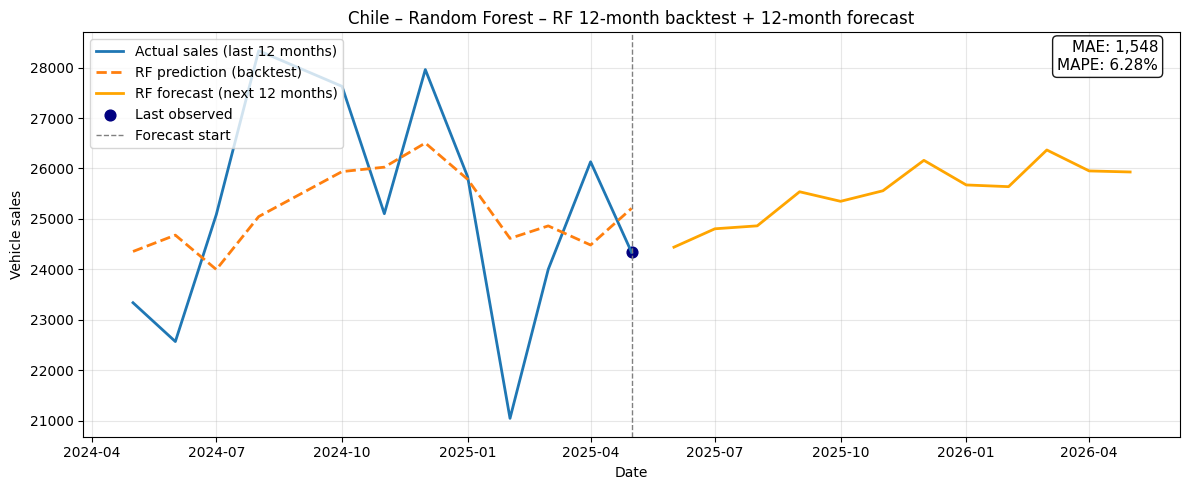

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_rf_backtest_forecast_with_errors(
    country_name,
    hist_df,        # full history with ['Date','Vehicle_Sales', ...]
    bt_df,          # RF backtest df: ['Date','actual','pred']
    fcst_series,    # RF 12m forecast (Series)
    lookback_start, # 'YYYY-MM-01' start of 12-month window
    last_actual_date, # 'YYYY-MM-01' last observed month
    save_path=None,
):
    # --- prep data ---
    hist_df = hist_df.copy()
    hist_df["Date"] = pd.to_datetime(hist_df["Date"])
    bt_df = bt_df.copy()
    bt_df["Date"] = pd.to_datetime(bt_df["Date"])
    fcst_series = fcst_series.copy()
    fcst_series.index = pd.to_datetime(fcst_series.index)

    lookback_start = pd.to_datetime(lookback_start)
    last_actual_date = pd.to_datetime(last_actual_date)

    # 12-month history window
    hist_window = hist_df[
        (hist_df["Date"] >= lookback_start) &
        (hist_df["Date"] <= last_actual_date)
    ]

    # Backtest window (same dates)
    bt_window = bt_df[
        (bt_df["Date"] >= lookback_start) &
        (bt_df["Date"] <= last_actual_date)
    ]

    # Future forecast (strictly after last_actual_date)
    fcst_future = fcst_series[fcst_series.index > last_actual_date]

    # Error metrics for this 12-month window
    mae = np.mean(np.abs(bt_window["actual"] - bt_window["pred"]))
    mape = (
        np.mean(
            np.abs(bt_window["actual"] - bt_window["pred"]) /
            np.abs(bt_window["actual"])
        ) * 100
    )

    # --- plotting ---
    fig, ax = plt.subplots(figsize=(12, 5))

    # Actual sales
    ax.plot(
        hist_window["Date"],
        hist_window["Vehicle_Sales"],
        label="Actual sales (last 12 months)",
        linewidth=2,
    )

    # RF backtest prediction
    ax.plot(
        bt_window["Date"],
        bt_window["pred"],
        label="RF prediction (backtest)",
        linestyle="--",
        linewidth=2,
    )

    # RF forecast (next 12 months)
    ax.plot(
        fcst_future.index,
        fcst_future.values,
        label="RF forecast (next 12 months)",
        linewidth=2,
        color="orange",
    )

    # Last observed point
    last_row = hist_window.iloc[-1]
    ax.scatter(
        last_row["Date"],
        last_row["Vehicle_Sales"],
        s=60,
        label="Last observed",
        color="navy",
    )

    # Vertical line at forecast start
    ax.axvline(
        last_actual_date,
        linestyle="--",
        color="gray",
        linewidth=1,
        label="Forecast start",
    )

    # MAE / MAPE box
    ax.text(
        0.98, 0.98,
        f"MAE: {mae:,.0f}\nMAPE: {mape:.2f}%",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=11,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.9),
    )

    ax.set_title(f"{country_name} – RF 12-month backtest + 12-month forecast")
    ax.set_xlabel("Date")
    ax.set_ylabel("Vehicle sales")
    ax.legend(loc="upper left")
    ax.grid(True, alpha=0.3)
    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved chart to: {save_path}")

    plt.show()


# ==== CALLS FOR YOUR DATA ====

plot_rf_backtest_forecast_with_errors(
    country_name="Chile – Random Forest",
    hist_df=ch_ml_feat,
    bt_df=bt_ch_rf,
    fcst_series=rf_ch_forecast.set_index("Date")["Forecast"],
    lookback_start="2024-05-01",
    last_actual_date="2025-05-01",
    save_path="Chile_RF_12m_backtest_forecast.jpg",
)



Saved chart to: Peru_RF_12m_backtest_forecast.jpg


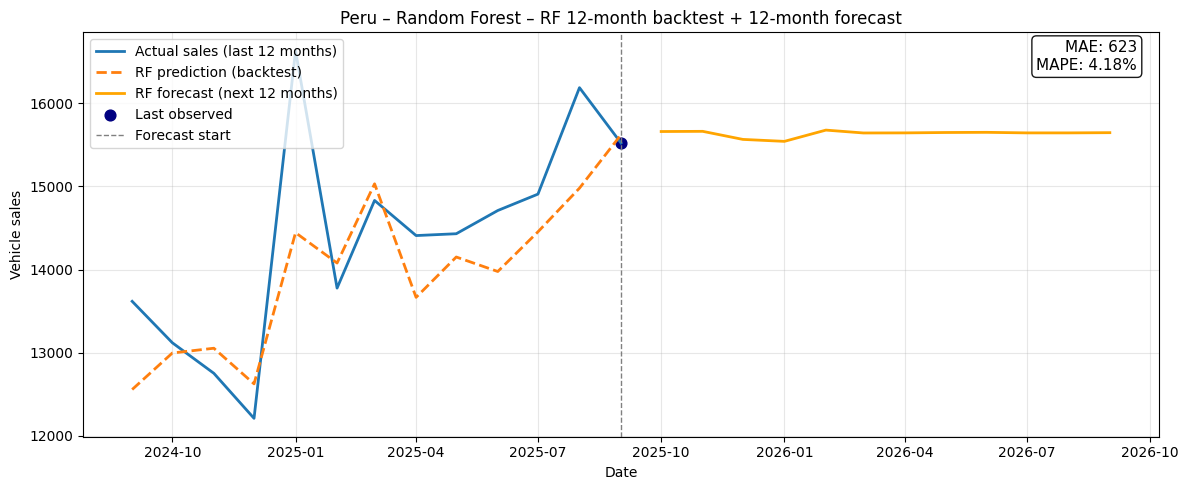

In [ ]:
# Peru – RF benchmark (12m history: Sept 2024–Sept 2025)

# ==== CALLS FOR YOUR DATA ====

plot_rf_backtest_forecast_with_errors(
    country_name="Peru – Random Forest",
    hist_df=pe_ml_feat,
    bt_df=bt_pe_rf,
    fcst_series=rf_pe_forecast.set_index("Date")["Forecast"],
    lookback_start="2024-09-01",
    last_actual_date="2025-09-01",
    save_path="Peru_RF_12m_backtest_forecast.jpg",
)

**Key Takeaway:** In Peru, recursive Random Forest forecasts converge to a steady state as lagged and macro features stabilise. This reflects the market’s low volatility and weak seasonality rather than a modelling failure, , and highlights a known limitation of tree-based models: they do extrapolate only if features extrapolate. As a result, while Random Forest is well suited for near-term forecasting in stable markets, classical time-series or foundation models are more appropriate for long-horizon demand planning.

### Random Forest – Forecasting Suitability Summary

| Use case                   | Suitability |
|----------------------------|-------------|
| Short-term prediction      | High |
| Stable markets             | High |
| Scenario-based forecasting | Medium–High |
| Long-horizon extrapolation | Low |
| Trend discovery            | Low |


## Random Forest Feature Importance Plot

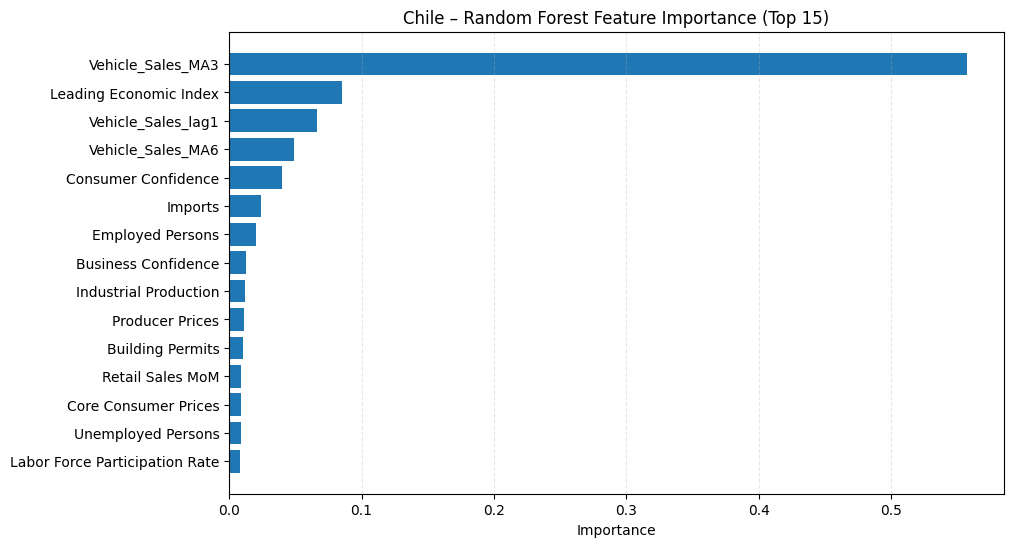

In [ ]:
feature_cols = rf_cols_chile
X = ch_ml_feat[feature_cols]
y = ch_ml_feat["Vehicle_Sales"]

rf = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42, n_jobs=-1)
rf.fit(X, y)

imp = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(imp.tail(15).index, imp.tail(15).values)
plt.title("Chile – Random Forest Feature Importance (Top 15)")
plt.xlabel("Importance")
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.show()


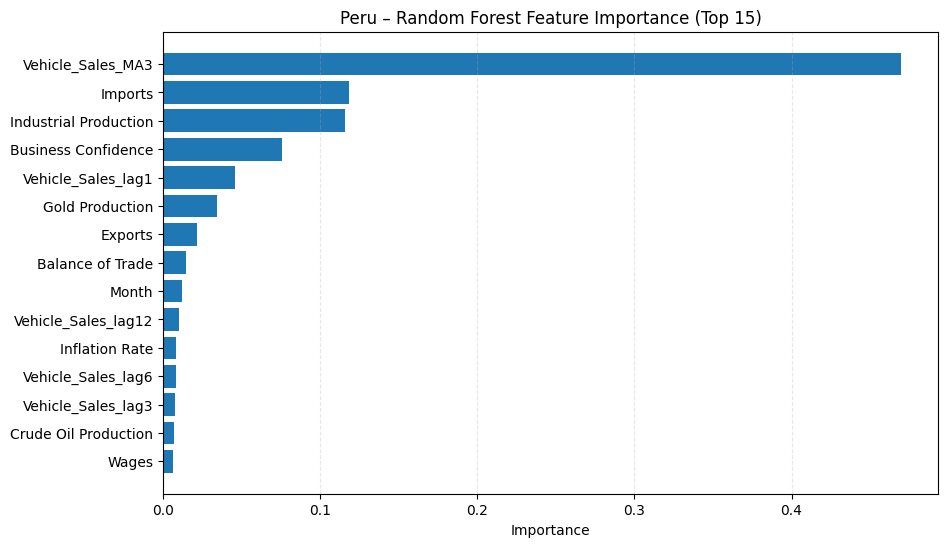

In [ ]:
feature_cols = rf_cols_peru
X = pe_ml_feat[feature_cols]
y = pe_ml_feat["Vehicle_Sales"]

rf = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42, n_jobs=-1)
rf.fit(X, y)

imp = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(imp.tail(15).index, imp.tail(15).values)
plt.title("Peru – Random Forest Feature Importance (Top 15)")
plt.xlabel("Importance")
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.show()

In [ ]:
[x for x in globals().keys() if "bt_" in x.lower()]


['bt_ch_sarima',
 'bt_pe_sarima',
 'bt_ch_sarimax',
 'bt_pe_sarimax',
 'bt_ch_rf',
 'bt_pe_rf']

In [ ]:
import pandas as pd

# --- robust summary helper (works with MAE/mae, MAPE/mape, etc.) ---
def summarise_backtest(bt_df, country, model_name):
    cols = {c.lower(): c for c in bt_df.columns}

    def get_mean(col):
        key = cols.get(col.lower())
        return bt_df[key].mean() if key is not None else None

    return {
        "Country": country,
        "Model": model_name,
        "MAE_mean":  get_mean("mae"),
        "RMSE_mean": get_mean("rmse"),
        "MAPE_mean": get_mean("mape"),
    }

# --- SARIMA / SARIMAX summary ---
summary_sarima = pd.DataFrame([
    summarise_backtest(bt_ch_sarima,  "Chile", "SARIMA"),
    summarise_backtest(bt_ch_sarimax, "Chile", "SARIMAX"),
    summarise_backtest(bt_pe_sarima,  "Peru",  "SARIMA"),
    summarise_backtest(bt_pe_sarimax, "Peru",  "SARIMAX"),
])

# --- ML summary (RF, XGBoost, LightGBM) ---
summary_ml = pd.DataFrame([
    summarise_backtest(bt_ch_rf,   "Chile", "RandomForest"),
    summarise_backtest(bt_pe_rf,   "Peru",  "RandomForest"),
])

# --- final combined table (NO classical) ---
summary_all = (
    pd.concat([summary_ml, summary_sarima], ignore_index=True)
      .sort_values(["Country", "MAPE_mean"], ascending=[True, True])
      .reset_index(drop=True)
)

summary_all


,Country,Model,MAE_mean,RMSE_mean,MAPE_mean
0,Chile,RandomForest,"1,679.55",None,6.78
1,Chile,SARIMAX,"1,770.10",None,7.03
2,Chile,SARIMA,"2,110.48",None,8.36
3,Peru,RandomForest,773.73,None,5.83
4,Peru,SARIMA,942.38,None,7.11
5,Peru,SARIMAX,"1,181.60",None,8.80


## Cross-Market Insights (Very Important)

-**Across both Chile and Peru, Random Forest consistently delivers the strongest predictive performance,** achieving the lowest errors in each market (Chile: MAE 1,680, MAPE 6.78%; Peru: MAE 774, MAPE 5.83%).

-Chile shows smaller gaps between models, suggesting multiple viable approaches.

-Peru shows larger performance separation, indicating a simpler but more ML-friendly structure.

- SARIMAX adds value in Chile but not in Peru, consistent with EDA (stronger seasonality and macro sensitivity in Chile).



# **Agentic AI for Deep learning & TimeGPT**

## Setup: Install Libraries & Panel Data

In [ ]:
# Setup: install libraries + prepare panel dataframe =====

!pip install neuralforecast nixtla --quiet

from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATS, PatchTST
from nixtla import NixtlaClient  # TimeGPT client

# Build panel format: [unique_id, ds, y] for both countries
ch_ts = ch_ml[["Date", "Vehicle_Sales"]].copy()
ch_ts["unique_id"] = "Chile"
ch_ts = ch_ts.rename(columns={"Date": "ds", "Vehicle_Sales": "y"})

pe_ts = pe_ml[["Date", "Vehicle_Sales"]].copy()
pe_ts["unique_id"] = "Peru"
pe_ts = pe_ts.rename(columns={"Date": "ds", "Vehicle_Sales": "y"})

panel_df = pd.concat([ch_ts, pe_ts], ignore_index=True)
panel_df = panel_df.sort_values(["unique_id", "ds"]).reset_index(drop=True)

display(panel_df.head())

# Train/test splitter (per country)
def ts_train_test(df, country_name, horizon=12):
    sub = df[df["unique_id"] == country_name].copy().sort_values("ds")
    train = sub.iloc[:-horizon]
    test  = sub.iloc[-horizon:]
    return train, test

H = 12  # 12-month forecast horizon

ch_train_df, ch_test_df = ts_train_test(panel_df, "Chile", horizon=H)
pe_train_df, pe_test_df = ts_train_test(panel_df, "Peru",  horizon=H)

len(ch_train_df), len(ch_test_df), len(pe_train_df), len(pe_test_df)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.9/269.9 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.5/48.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.4/287.4 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.4/72.4 MB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 55.7 MB/s eta 0:00:00


,ds,y,unique_id
0,2019-01-01,"36,543.00",Chile
1,2019-02-01,"27,912.00",Chile
2,2019-03-01,"30,199.00",Chile
3,2019-04-01,"32,716.00",Chile
4,2019-05-01,"31,204.00",Chile


(60, 12, 165, 12)

## Deep Model Wrappers: PatchTST


In [ ]:
# Deep model wrappers: PatchTST

def model_patchtst(country_name, train_df, horizon=12):
    """
    PatchTST deep model for a single country.
    """
    patchtst = PatchTST(
        h=horizon,
        input_size=36,
        max_steps=200,
        batch_size=32,
        n_heads=4,
        random_seed=42,
    )
    nf = NeuralForecast(models=[patchtst], freq="MS")
    nf.fit(train_df)
    fcst = nf.predict().reset_index()
    fc_country = fcst[fcst["unique_id"] == country_name].tail(horizon)
    return fc_country["PatchTST"].values


## TimeGPT (Foundation Model) Wrapper & API Key

For security reasons, the TimeGPT / Nixtla API key is **not hard-coded** in this notebook.
Instead, it is loaded securely at runtime using environment variables.


In [ ]:
from getpass import getpass

print("🔐 Please enter your full NIXTLA / TimeGPT API key:")
api_key = getpass()

import os
os.environ["NIXTLA_API_KEY"] = api_key

if api_key:
    print("✅ NIXTLA_API_KEY successfully stored in environment.")
else:
    print("⚠️ No key entered. TimeGPT will fall back to a simple naive forecast.")


🔐 Please enter your full NIXTLA / TimeGPT API key:
··········
✅ NIXTLA_API_KEY successfully stored in environment.


In [ ]:
# TimeGPT (foundation model) wrapper

def _get_timegpt_client():
    """
    Create a Nixtla TimeGPT client if an API key is available.
    Looks for NIXTLA_API_KEY in the environment.
    """
    api_key = os.getenv("NIXTLA_API_KEY")
    if not api_key:
        print(
            "[TimeGPT] No NIXTLA_API_KEY found in environment. "
            "TimeGPT will fall back to a simple naive forecast."
        )
        return None
    return NixtlaClient(api_key=api_key)

timegpt_client = _get_timegpt_client()


def model_timegpt(country_name, train_df, horizon=12):
    """
    Real TimeGPT forecast if API key is set.
    train_df: ['unique_id','ds','y'] for that country.
    Returns: np.array of length = horizon.
    """
    if timegpt_client is None:
        # Fallback so notebook runs even without credentials
        y = train_df["y"].astype(float).values
        window = min(12, len(y))
        last_mean = y[-window:].mean()
        return np.repeat(last_mean, horizon)

    sub = train_df.copy()

    fcst_df = timegpt_client.forecast(
        df=sub,
        h=horizon,
        time_col="ds",
        target_col="y",
        id_col="unique_id",
        model="timegpt-1",
    )

    fc_country = fcst_df[fcst_df["unique_id"] == country_name].tail(horizon)
    return fc_country["TimeGPT"].values


## Metrics Helper

In [ ]:
# Metrics helper: MAE, MAPE, RMSE
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

def compute_metrics(y_true, y_pred):
    """
    Compute MAE, MAPE, RMSE, with NaN-safe masking.
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mask = (~np.isnan(y_true)) & (~np.isnan(y_pred))
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    mae  = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {"MAE": mae, "MAPE": mape, "RMSE": rmse}

## Agent 1 – Model Plan

In [ ]:
# Agent 1: model plan (all real models)

def agent1_deep_model_plan(country_name):
    """
    Decide which models to run for a given country.
    Here we run two real models: PatchTST, and TimeGPT.
    """
    return {
        "country": country_name,
        "models_to_run": ["PATCHTST", "TIMEGPT"],
    }


## Agent 2 – Run Deep + Foundation Models

In [ ]:
# Agent 2: run deep + foundation models (now returns backtest + future forecasts)

def run_deep_foundation_models(country_name, train_df, test_df, plan, h_future=12):
    """
    Execute all models in the plan for a given country.

    Inputs:
      train_df/test_df: columns ['unique_id','ds','y'] (monthly, freq='MS')
      plan: dict with key 'models_to_run'
      h_future: forecast horizon beyond the last observed point (default 12)

    Returns:
      results: list of dicts with:
        - country, model
        - y_true_test (list)
        - y_pred_test (list)   # backtest predictions aligned to test_df['ds']
        - y_pred_future (list) # forecast next h_future months beyond last observed date
        - metrics (dict) computed on test window
    """
    h_test = len(test_df)
    y_test = test_df["y"].values

    # Full history used for the forward forecast (train + test)
    full_df = pd.concat([train_df, test_df], ignore_index=True).sort_values("ds")

    results = []

    for model_name in plan["models_to_run"]:
        if model_name == "PATCHTST":
            y_pred_test = model_patchtst(country_name, train_df, horizon=h_test)
            y_pred_future = model_patchtst(country_name, full_df, horizon=h_future)

        elif model_name == "TIMEGPT":
            y_pred_test = model_timegpt(country_name, train_df, horizon=h_test)
            y_pred_future = model_timegpt(country_name, full_df, horizon=h_future)

        else:
            continue

        y_pred_test = np.asarray(y_pred_test, dtype=float).reshape(-1)[:h_test]
        y_pred_future = np.asarray(y_pred_future, dtype=float).reshape(-1)[:h_future]

        mets = compute_metrics(y_test, y_pred_test)

        results.append(
            {
                "country": country_name,
                "model": model_name,
                "y_true_test": y_test.tolist(),
                "y_pred_test": y_pred_test.tolist(),
                "y_pred_future": y_pred_future.tolist(),
                "metrics": mets,
            }
        )

    return results


## Agent 3 – Evaluator & Best-Model Selector

In [ ]:
# Agent 3: evaluate & select best model

def agent3_evaluator_selector(country_name, results):
    """
    Turn model results into a metrics dataframe and choose the best model.
    """
    rows = []

    for r in results:
        model_name = r["model"]
        y_true = np.array(r["y_true_test"], dtype=float)
        y_pred = np.array(r["y_pred_test"], dtype=float)

        mask = (~np.isnan(y_true)) & (~np.isnan(y_pred))
        y_true_clean = y_true[mask]
        y_pred_clean = y_pred[mask]

        mae  = mean_absolute_error(y_true_clean, y_pred_clean)
        mape = mean_absolute_percentage_error(y_true_clean, y_pred_clean)
        rmse = np.sqrt(mean_squared_error(y_true_clean, y_pred_clean))

        rows.append(
            {
                "country": country_name,
                "model": model_name,
                "MAE": mae,
                "MAPE": mape,
                "RMSE": rmse,
            }
        )

    metrics_df = (
        pd.DataFrame(rows)
        .sort_values(["MAPE", "RMSE"])
        .reset_index(drop=True)
    )

    best_row = metrics_df.iloc[0]
    decision = {
        "country": country_name,
        "best_model": best_row["model"],
        "reason": (
            f"Selected {best_row['model']} for {country_name} because it has "
            f"the lowest MAPE ({best_row['MAPE']:.2%}) and strong RMSE "
            f"({best_row['RMSE']:.1f})."
        ),
    }

    return decision, metrics_df


## Country Pipeline & Run for Chile & Peru

In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor

def rf_model():
    return RandomForestRegressor(
        n_estimators=500,
        random_state=42,
        max_depth=6
    )

def backtest_regressor_auto(df, target, feature_cols, n_test=24, model_fn=None):
    """
    Rolling-origin backtest over the last n_test observations.

    Returns a DataFrame with columns:
      - 'Date'
      - 'actual'
      - 'pred'
      - 'mae'
      - 'mape'
    """
    df_bt = df.sort_values("Date").reset_index(drop=True).copy()

    # ensure we don't ask for more test points than we have rows
    n = len(df_bt)
    n_test = min(n_test, max(1, n - 20))  # keep at least 20 points for training
    start_idx = n - n_test

    results = []

    for i in range(start_idx, n):
        train = df_bt.iloc[:i]
        test  = df_bt.iloc[i:i+1]

        X_train = train[feature_cols]
        y_train = train[target]
        X_test  = test[feature_cols]
        y_test  = test[target]

        model = model_fn()
        model.fit(X_train, y_train)
        pred_val   = float(model.predict(X_test)[0])
        actual_val = float(y_test.iloc[0])

        mae_val  = abs(actual_val - pred_val)
        mape_val = abs(actual_val - pred_val) / abs(actual_val) * 100 if actual_val != 0 else np.nan

        results.append({
            "Date":   test["Date"].iloc[0],
            "actual": actual_val,
            "pred":   pred_val,
            "mae":    mae_val,
            "mape":   mape_val
        })

    return pd.DataFrame(results)

In [ ]:
# =========================================
# 15.8 Country Pipeline & Run (Chile & Peru)
# Fix: enforce true monthly regularity for TimeGPT
# =========================================

import pandas as pd
from IPython.display import display

# --- Macro summaries ---
ch_macro_summary = (
    "Chile shows high long-run growth but strong volatility. Large swings occur "
    "around COVID-19 and the 2022–23 inflation and lending-rate shock. Demand is "
    "sensitive to consumer confidence, industrial production and import cycles."
)

pe_macro_summary = (
    "Peru shows smoother GDP growth, a temporary inflation spike that normalises "
    "quickly, strong expansion in consumer and private-sector credit, rising wages "
    "and relatively stable imports. This creates a more predictable demand base "
    "for vehicles."
)

# --- Helper: clean + force strict monthly panel ---
def make_strict_monthly_panel(df, unique_id, agg="mean", fill_method="interpolate"):
    d = df.copy()

    # 1) force datetime + month-start
    d["ds"] = pd.to_datetime(d["ds"])
    d["ds"] = d["ds"].dt.to_period("M").dt.to_timestamp(how="start")

    # 2) add id (required by Nixtla utilsforecast)
    d["unique_id"] = unique_id

    # 3) aggregate (removes duplicates within a month)
    if agg == "sum":
        d = d.groupby(["unique_id", "ds"], as_index=False)["y"].sum()
    else:
        d = d.groupby(["unique_id", "ds"], as_index=False)["y"].mean()

    # 4) reindex to complete monthly range (no gaps in ds)
    full = pd.date_range(d["ds"].min(), d["ds"].max(), freq="MS")
    d = (
        d.set_index(["unique_id", "ds"])
         .reindex(pd.MultiIndex.from_product([[unique_id], full], names=["unique_id", "ds"]))
         .reset_index()
    )

    # 5) fill y (IMPORTANT: do NOT drop missing months)
    if fill_method == "interpolate":
        d["y"] = d["y"].interpolate(limit_direction="both")
        d["y"] = d["y"].ffill().bfill()
    elif fill_method == "ffill":
        d["y"] = d["y"].ffill().bfill()
    else:
        d["y"] = d["y"].ffill().bfill()

    # 6) final hygiene (sorted, unique, correct dtype)
    d = d.sort_values(["unique_id", "ds"]).drop_duplicates(["unique_id", "ds"])
    d["ds"] = pd.to_datetime(d["ds"])

    return d


def run_country_deep_pipeline(country_name, train_df, test_df, macro_summary):
    # NOTE: these must already be in the standard format with columns: unique_id | ds | y
    # but if they aren’t, this forces them to be safe for TimeGPT.

    train_df = make_strict_monthly_panel(train_df, unique_id=country_name, agg="mean", fill_method="interpolate")
    test_df  = make_strict_monthly_panel(test_df,  unique_id=country_name, agg="mean", fill_method="interpolate")

    # Agent 1 – plan (must exist earlier)
    plan = agent1_deep_model_plan(country_name)

    # Agent 2 – run deep + foundation models (must exist earlier)
    # If your TimeGPT wrapper accepts freq, pass freq="MS" there too.
    results = run_deep_foundation_models(country_name, train_df, test_df, plan)

    # Agent 3 – select best (must exist earlier)
    decision, metrics_df = agent3_evaluator_selector(country_name, results)

    best_model = decision["best_model"]
    best_pred  = next(r for r in results if r["model"] == best_model)["y_pred_test"]

    return {
        "country": country_name,
        "decision": decision,
        "metrics_df": metrics_df,
        "results": results,
        "best_forecast": best_pred,
        "test_index": test_df["ds"].dt.to_period("M").astype(str).tolist(),
        "macro_summary": macro_summary,
    }


# --- Run pipeline for both countries ---
ch_deep_results = run_country_deep_pipeline("Chile", ch_train_df, ch_test_df, ch_macro_summary)
pe_deep_results = run_country_deep_pipeline("Peru",  pe_train_df, pe_test_df, pe_macro_summary)

display(ch_deep_results["metrics_df"])
display(pe_deep_results["metrics_df"])

ch_deep_results["decision"], pe_deep_results["decision"]


INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE               │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d     │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm      │      0 │ train │     0 │
│ 3 │ model        │ PatchTST_backbone │  406 K │ train │     0 │
└───┴──────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 406 K                                                                                            
Non-trainable params: 3                                                                                            
Total params: 406 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 90                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=200` reached.


...

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

,country,model,MAE,MAPE,RMSE
0,Chile,TIMEGPT,"2,048.04",0.09,"2,542.15"
1,Chile,PATCHTST,"3,366.22",0.14,"4,282.31"


,country,model,MAE,MAPE,RMSE
0,Peru,PATCHTST,"1,372.58",0.09,"1,564.80"
1,Peru,TIMEGPT,"2,020.96",0.13,"2,384.10"


({'country': 'Chile',
  'best_model': 'TIMEGPT',
  'reason': 'Selected TIMEGPT for Chile because it has the lowest MAPE (8.64%) and strong RMSE (2542.2).'},
 {'country': 'Peru',
  'best_model': 'PATCHTST',
  'reason': 'Selected PATCHTST for Peru because it has the lowest MAPE (9.22%) and strong RMSE (1564.8).'})

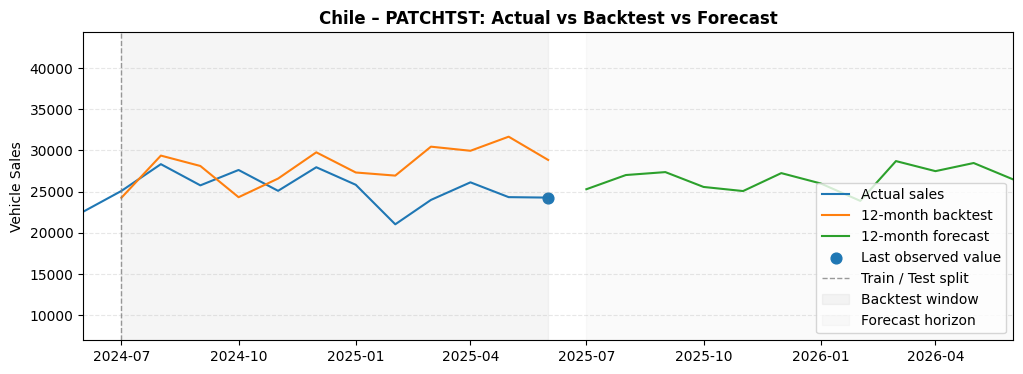

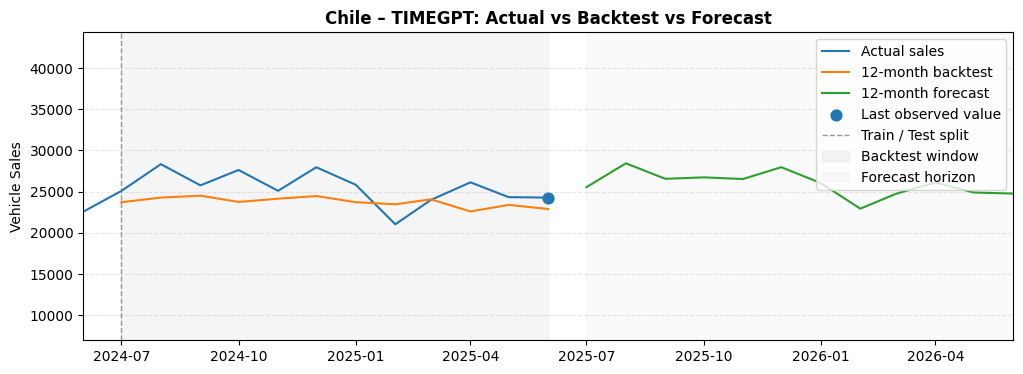

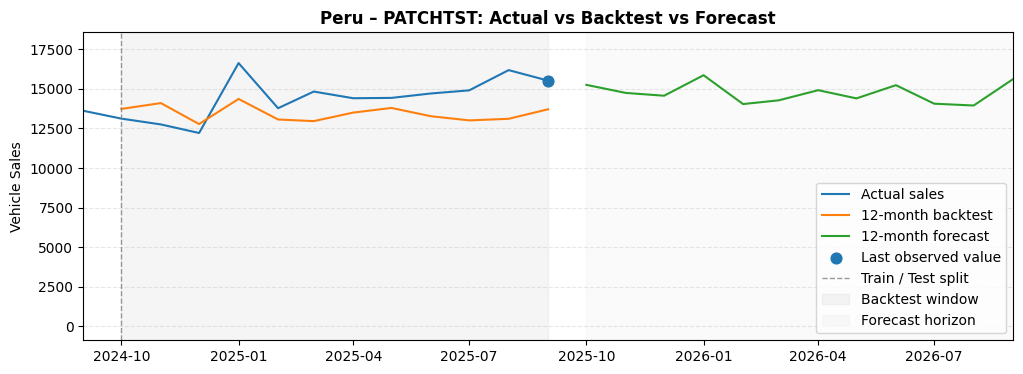

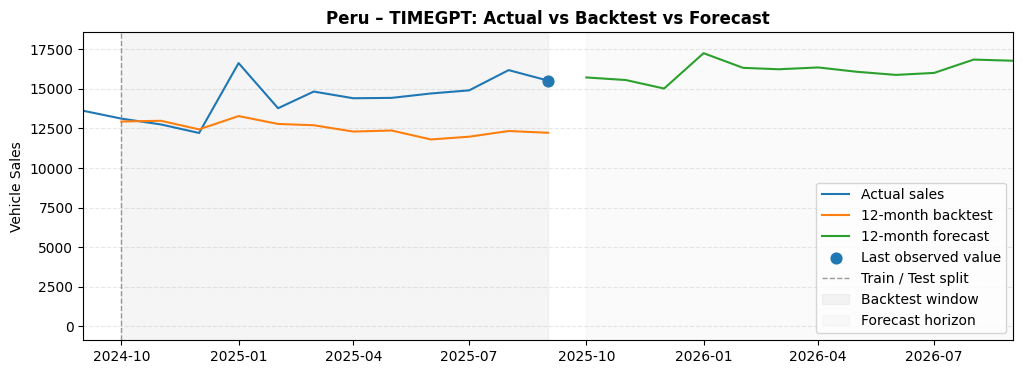

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def _get_model_result(results, model_name):
    return next(r for r in results if r["model"].lower() == model_name.lower())

def plot_actual_backtest_forecast(
    country,
    train_df,
    test_df,
    model_name,
    y_pred_test,
    y_pred_future=None,
    h_future=12,
    xlim_dates=None
):
    """
    Plots:
      1) Actual sales (train + test)
      2) 12-month backtest predictions (test window)
      3) 12-month forecast
      4) Last observed value
      5) Train/Test split marker (+ shaded windows)
      Optional: x-axis date limits via xlim_dates=(start, end)
    """

    actual = pd.concat([train_df, test_df], ignore_index=True).copy()
    actual["ds"] = pd.to_datetime(actual["ds"])
    actual = actual.sort_values("ds")

    test_dates = pd.to_datetime(test_df["ds"]).sort_values().reset_index(drop=True)
    y_pred_test = np.asarray(y_pred_test, dtype=float).reshape(-1)

    split_date = test_dates.min()
    last_date = actual["ds"].max()
    last_val = actual.loc[actual["ds"] == last_date, "y"].iloc[-1]

    plt.figure(figsize=(12, 4))

    # Actual
    plt.plot(actual["ds"], actual["y"], label="Actual sales")

    # Backtest
    plt.plot(test_dates, y_pred_test, label="12-month backtest")

    # Forecast
    future_dates = None
    if y_pred_future is not None:
        y_pred_future = np.asarray(y_pred_future, dtype=float).reshape(-1)
        future_dates = pd.date_range(
            last_date + pd.offsets.MonthBegin(1),
            periods=h_future,
            freq="MS"
        )
        plt.plot(future_dates, y_pred_future, label="12-month forecast")

    # Last observed
    plt.scatter([last_date], [last_val], s=60, label="Last observed value")

    # Train/Test split line
    plt.axvline(
        x=split_date,
        color="gray",
        linestyle="--",
        linewidth=1,
        alpha=0.8,
        label="Train / Test split"
    )

    # Shaded windows (optional but very clear)
    plt.axvspan(split_date, last_date, color="gray", alpha=0.08, label="Backtest window")
    if future_dates is not None:
        plt.axvspan(future_dates.min(), future_dates.max(),
                    color="gray", alpha=0.04, label="Forecast horizon")

    # Limit x-axis dates (your request)
    if xlim_dates is not None:
        start, end = pd.to_datetime(xlim_dates[0]), pd.to_datetime(xlim_dates[1])
        plt.xlim(start, end)

    plt.title(f"{country} – {model_name}: Actual vs Backtest vs Forecast", fontweight="bold")
    plt.ylabel("Vehicle Sales")
    plt.grid(axis="y", linestyle="--", alpha=0.3)

    # Deduplicate legend labels
    handles, labels = plt.gca().get_legend_handles_labels()
    dedup = dict(zip(labels, handles))
    plt.legend(dedup.values(), dedup.keys())

    plt.show()


# =========================
# Plot loops (Chile + Peru)
# =========================

# Chile: show only 2024-01 to 2024-12
for model_name in ["PATCHTST", "TIMEGPT"]:
    r = _get_model_result(ch_deep_results["results"], model_name)
    plot_actual_backtest_forecast(
        country="Chile",
        train_df=ch_train_df,
        test_df=ch_test_df,
        model_name=model_name,
        y_pred_test=r["y_pred_test"],
        y_pred_future=r.get("y_pred_future"),
        h_future=12,
        xlim_dates=("2024-06-01", "2026-06-01")
    )

# Peru: show only 2024-09 to 2025-09
for model_name in ["PATCHTST", "TIMEGPT"]:
    r = _get_model_result(pe_deep_results["results"], model_name)
    plot_actual_backtest_forecast(
        country="Peru",
        train_df=pe_train_df,
        test_df=pe_test_df,
        model_name=model_name,
        y_pred_test=r["y_pred_test"],
        y_pred_future=r.get("y_pred_future"),
        h_future=12,
        xlim_dates=("2024-09-01", "2026-09-01")
    )


In [ ]:
import pandas as pd
import numpy as np

# 1) Start from your existing classical+ML table
base = summary_all.copy()

# Ensure consistent column names
base = base.rename(columns={
    "Country": "Country",
    "Model": "Model",
    "MAE_mean": "MAE",
    "RMSE_mean": "RMSE",
    "MAPE_mean": "MAPE"
})

# Convert None -> NaN
base["RMSE"] = pd.to_numeric(base["RMSE"], errors="coerce")
base["MAE"]  = pd.to_numeric(base["MAE"], errors="coerce")
base["MAPE"] = pd.to_numeric(base["MAPE"], errors="coerce")  # already in %

# 2) Deep models table (Chile + Peru)
deep = pd.concat(
    [ch_deep_results["metrics_df"], pe_deep_results["metrics_df"]],
    ignore_index=True
).copy()

# Standardize column names
deep = deep.rename(columns={
    "country": "Country",
    "model": "Model",
    "MAE": "MAE",
    "RMSE": "RMSE",
    "MAPE": "MAPE"
})

# Deep MAPE is currently 0.xx (fraction). Convert to percent to match base tables.
# (e.g., 0.08 -> 8.0)
deep["MAPE"] = pd.to_numeric(deep["MAPE"], errors="coerce") * 100

# Make numeric
deep["MAE"]  = pd.to_numeric(deep["MAE"], errors="coerce")
deep["RMSE"] = pd.to_numeric(deep["RMSE"], errors="coerce")

# 3) Combine everything
summary_models_all = (
    pd.concat([base[["Country","Model","MAE","RMSE","MAPE"]],
               deep[["Country","Model","MAE","RMSE","MAPE"]]],
              ignore_index=True)
      .sort_values(["Country", "MAPE"], ascending=[True, True])
      .reset_index(drop=True)
)


In [ ]:
import pandas as pd

# Ensure MAPE is numeric (safe)
summary_models_all["MAPE"] = pd.to_numeric(summary_models_all["MAPE"], errors="coerce")

# Rank within each country by MAPE (lower is better)
summary_models_all["Rank"] = (
    summary_models_all.groupby("Country")["MAPE"]
    .rank(method="dense", ascending=True)
    .astype("Int64")
)

# Best model flag
summary_models_all["Best_Model"] = summary_models_all["Rank"].eq(1)

# Sort nicely
summary_models_all = summary_models_all.sort_values(["Country", "Rank", "MAPE"]).reset_index(drop=True)

summary_models_all = summary_models_all.drop(columns=["RMSE"], errors="ignore")

summary_models_all


,Country,Model,MAE,MAPE,Rank,Best_Model
0,Chile,RandomForest,"1,679.55",6.78,1,True
1,Chile,SARIMAX,"1,770.10",7.03,2,False
2,Chile,SARIMA,"2,110.48",8.36,3,False
3,Chile,TIMEGPT,"2,048.04",8.64,4,False
4,Chile,PATCHTST,"3,366.22",14.03,5,False
5,Peru,RandomForest,773.73,5.83,1,True
6,Peru,SARIMA,942.38,7.11,2,False
7,Peru,SARIMAX,"1,181.60",8.80,3,False
8,Peru,PATCHTST,"1,372.58",9.22,4,False
9,Peru,TIMEGPT,"2,020.96",13.34,5,False


#CONCLUSIONS
1. **Random Forest is the top-performing model in both Chile and Peru**, delivering the lowest MAE and MAPE and confirming its strength for short-to-medium-term operational forecasting when demand dynamics are primarily driven by historical patterns.

2. **Classical models remain strong, explainable alternatives**, with SARIMAX performing best in Chile’s more volatile, macro-sensitive market, and SARIMA outperforming SARIMAX in Peru, where demand is more stable and internally driven.

3. **Higher model complexity does not guarantee better forecasts**: deep learning and foundation models (PatchTST, TimeGPT) underperform in both markets, reinforcing the importance of aligning model choice with data volume, market structure, and business needs rather than model sophistication alone.